# EDA — RMR tunnel support dataset

dataset: `rmr_dataset.csv` — 1000 rows, 200 per class

going through distributions, correlations, span/depth effects, noise impact.
sections 6-8 are the most interesting ones


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.metrics import confusion_matrix
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.bbox'] = 'tight'

CLASS_COLORS = {'I':'#2ecc71', 'II':'#3498db', 'III':'#f39c12', 'IV':'#e67e22', 'V':'#e74c3c'}
CLASS_ORDER = ['I', 'II', 'III', 'IV', 'V']
COLORS_ORDERED = [CLASS_COLORS[c] for c in CLASS_ORDER]

RMR_FEATURE_COLS = ['UCS_MPa', 'RQD_percent', 'Joint_Spacing_m',
                    'Joint_Condition', 'Groundwater', 'Joint_Orientation_adj']
NEW_FEATURE_COLS = ['Excavation_Span_m', 'Depth_m', 'Excavation_Method']
FEATURE_COLS = RMR_FEATURE_COLS + NEW_FEATURE_COLS

TARGET_COLS = ['RMR', 'Bolt_Density_per_m2', 'Bolt_Length_m', 'Shotcrete_mm']

print(f'features: {len(FEATURE_COLS)}   targets: {len(TARGET_COLS)}')


features: 9   targets: 4


## 1. load & sanity checks


In [2]:
df = pd.read_csv('rmr_dataset.csv')

# handle both column name variants just in case
CLASS_COL = 'True_Rock_Class' if 'True_Rock_Class' in df.columns else 'Rock_Class'

print(f'shape: {df.shape}')
print(f'class col: {CLASS_COL}')
print()
for col in df.columns:
    print(f'  {col:<30} {df[col].dtype}')


shape: (1000, 19)
class col: True_Rock_Class

  UCS_MPa                        float64
  RQD_percent                    float64
  Joint_Spacing_m                float64
  Joint_Condition                int64
  Groundwater                    int64
  Joint_Orientation_adj          int64
  Excavation_Span_m              float64
  Depth_m                        float64
  Excavation_Method              int64
  RMR                            int64
  True_Rock_Class                object
  Measured_Rock_Class            object
  Bolt_Density_per_m2            float64
  Bolt_Length_m                  float64
  Shotcrete_mm                   float64
  UCS_clean                      float64
  RQD_clean                      float64
  JS_clean                       float64
  Depth_factor                   float64


In [3]:
df.head(10)

,UCS_MPa,RQD_percent,Joint_Spacing_m,Joint_Condition,Groundwater,Joint_Orientation_adj,Excavation_Span_m,Depth_m,Excavation_Method,RMR,True_Rock_Class,Measured_Rock_Class,Bolt_Density_per_m2,Bolt_Length_m,Shotcrete_mm,UCS_clean,RQD_clean,JS_clean,Depth_factor
0,207.89,88.69,1.6430,1,2,0,15.71,697.0,0,84,I,I,0.0,4.33,0.0,216.09,88.78,1.8303,1.042
1,218.46,85.46,1.2301,1,2,0,13.93,586.9,0,82,I,I,0.0,3.82,0.0,223.41,88.87,1.0727,1.030
2,114.45,88.73,1.5975,1,2,-2,15.61,327.0,1,82,I,I,0.0,4.79,0.0,106.57,83.09,1.6197,1.045
3,169.92,100.00,1.6843,1,2,0,13.99,734.0,1,92,I,I,0.0,4.28,0.0,165.57,96.65,1.6403,1.040
4,129.48,85.85,1.7546,1,1,-2,13.18,589.5,1,82,I,I,0.0,4.17,0.0,120.97,82.29,1.6021,1.107
5,232.35,87.81,0.8377,1,3,0,7.52,612.6,0,84,I,I,0.0,2.06,0.0,228.01,84.68,0.8700,1.025
6,205.89,87.12,0.9840,1,1,0,5.83,641.9,0,82,I,I,0.0,2.00,0.0,208.35,89.24,0.9935,1.046
7,171.87,96.51,1.3774,1,1,0,14.83,437.4,0,87,I,I,0.0,4.00,0.0,216.81,94.34,1.3392,1.000
8,191.70,96.72,1.5652,1,1,0,5.01,403.4,1,85,I,I,0.0,2.01,0.0,164.81,92.55,1.5009,1.014
9,205.98,96.92,2.0368,2,1,0,15.50,460.0,0,84,I,I,0.0,4.22,0.0,187.16,86.94,1.5091,1.018


In [5]:
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else 'no missing values')
print(f'duplicates: {df.duplicated().sum()}')
print(f'total rows: {len(df)}')

no missing values
duplicates: 0
total rows: 1000


In [7]:
df.describe().round(2)

,UCS_MPa,RQD_percent,Joint_Spacing_m,Joint_Condition,Groundwater,Joint_Orientation_adj,Excavation_Span_m,Depth_m,Excavation_Method,RMR,Bolt_Density_per_m2,Bolt_Length_m,Shotcrete_mm,UCS_clean,RQD_clean,JS_clean,Depth_factor
count,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00
mean,75.80,53.61,0.57,2.86,2.93,-5.63,9.95,467.90,0.48,49.00,0.68,4.95,98.37,75.80,53.66,0.57,1.34
std,62.47,29.38,0.55,1.30,1.36,4.47,3.42,244.88,0.50,28.76,0.65,1.61,86.53,61.67,29.13,0.54,0.21
min,1.00,0.00,0.01,1.00,1.00,-12.00,4.02,50.30,0.00,-3.00,0.00,2.00,0.00,1.00,0.22,0.01,1.00
25%,23.32,26.76,0.10,2.00,2.00,-10.00,6.89,256.20,0.00,25.00,0.16,3.53,18.30,23.47,24.85,0.10,1.10
50%,59.80,56.88,0.39,3.00,3.00,-5.00,9.86,469.75,0.00,50.00,0.44,5.00,85.85,58.49,57.79,0.41,1.50
75%,110.25,79.40,0.89,4.00,4.00,-2.00,12.93,669.08,1.00,77.00,1.00,6.70,167.35,112.71,80.20,0.93,1.50
max,281.08,100.00,2.51,5.00,5.00,0.00,16.00,899.40,1.00,92.00,1.78,7.00,250.00,249.03,99.95,2.00,1.50


## 2. class distribution


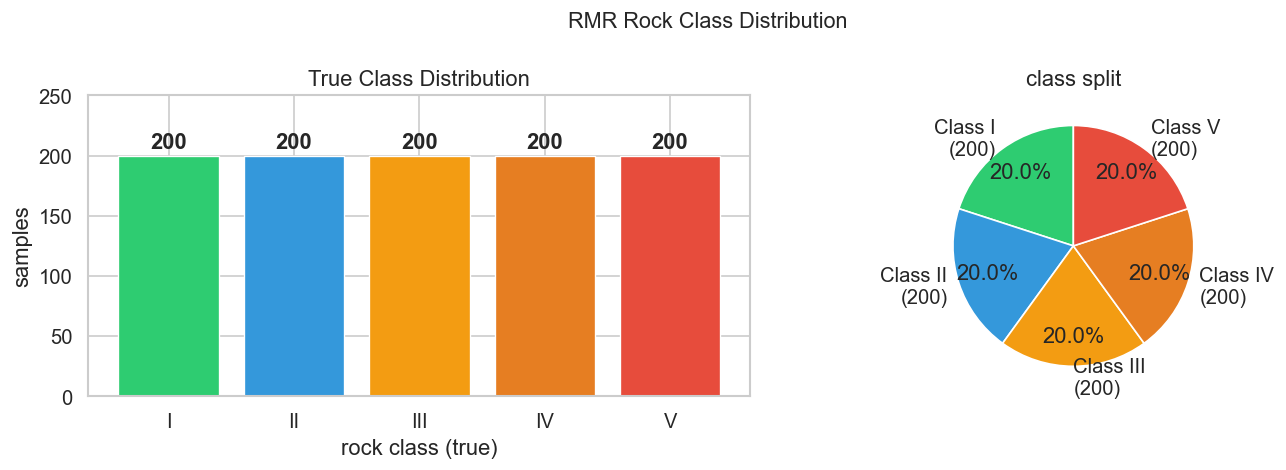

In [8]:
true_counts = df[CLASS_COL].value_counts().reindex(CLASS_ORDER)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

bars = axes[0].bar(CLASS_ORDER, true_counts.values,
                   color=COLORS_ORDERED, edgecolor='white', linewidth=0.8)
axes[0].set_xlabel('rock class (true)')
axes[0].set_ylabel('samples')
axes[0].set_title('True Class Distribution')
axes[0].set_ylim(0, 250)
for bar, val in zip(bars, true_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
                 str(val), ha='center', va='bottom', fontweight='bold')

labels = [f'Class {c}\n({v})' for c, v in zip(CLASS_ORDER, true_counts.values)]
axes[1].pie(true_counts.values, labels=labels, colors=COLORS_ORDERED,
            autopct='%1.1f%%', startangle=90, pctdistance=0.75)
axes[1].set_title('class split')

plt.suptitle('RMR Rock Class Distribution', fontsize=13)
plt.tight_layout()
plt.savefig('fig1_class_distribution.png')
plt.show()

## 3. RMR89 feature distributions

checking the 6 RMR input params look physically reasonable after noise


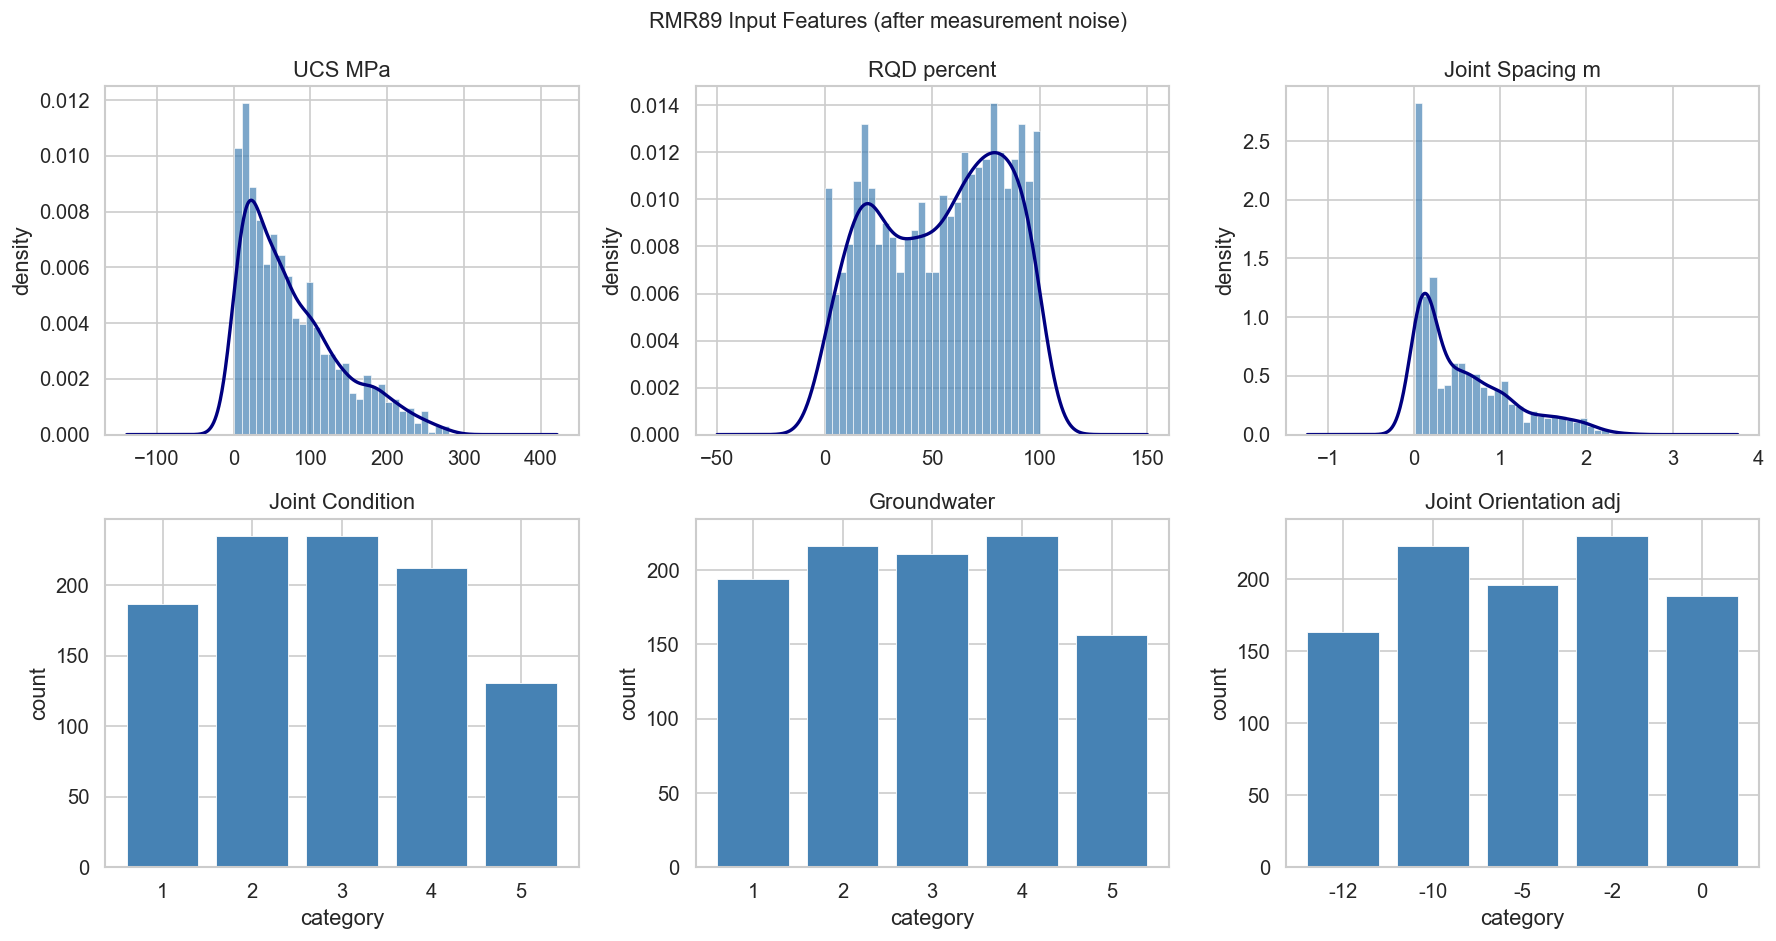

In [10]:
continuous_features = ['UCS_MPa', 'RQD_percent', 'Joint_Spacing_m']
discrete_features   = ['Joint_Condition', 'Groundwater', 'Joint_Orientation_adj']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for i, feat in enumerate(continuous_features):
    ax = axes[0, i]
    ax.hist(df[feat], bins=30, color='steelblue', edgecolor='white',
            linewidth=0.5, density=True, alpha=0.7)
    # pandas 2.x: Series.plot(kind='kde') still works but may warn about
    # deprecated ax kwarg in future — fine for now
    df[feat].plot(kind='kde', ax=ax, color='navy', linewidth=2)
    ax.set_title(feat.replace('_', ' '))
    ax.set_ylabel('density')

for i, feat in enumerate(discrete_features):
    ax = axes[1, i]
    counts = df[feat].value_counts().sort_index()
    ax.bar(counts.index.astype(str), counts.values,
           color='steelblue', edgecolor='white', linewidth=0.5)
    ax.set_title(feat.replace('_', ' '))
    ax.set_xlabel('category')
    ax.set_ylabel('count')

plt.suptitle('RMR89 Input Features (after measurement noise)', fontsize=13)
plt.tight_layout()
plt.savefig('fig2_rmr_feature_distributions.png')
plt.show()

## 4. design feature distributions — span, depth, method

these were sampled independently of rock class so distributions should look uniform
and show no class preference — checking that below


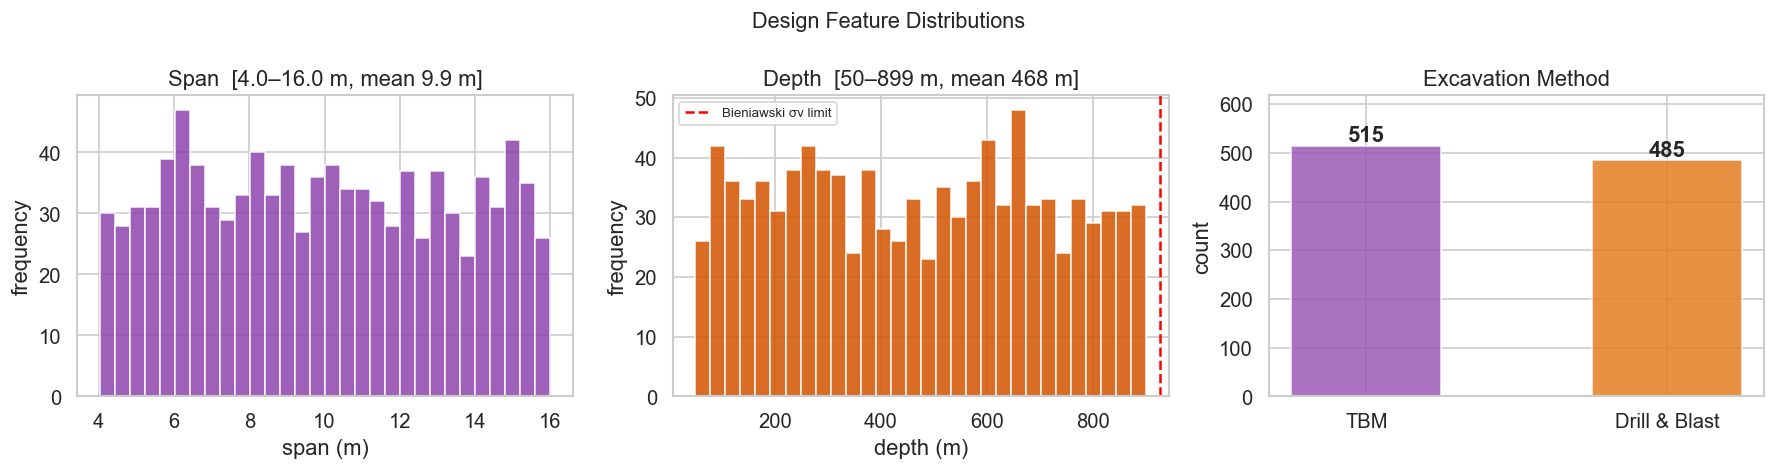

span:   mean=9.95  std=3.42 m
depth:  mean=467.9  std=244.9 m
method: TBM=515  D&B=485


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(df['Excavation_Span_m'], bins=30, color='#8e44ad', edgecolor='white', alpha=0.85)
axes[0].set_xlabel('span (m)')
axes[0].set_ylabel('frequency')
axes[0].set_title(
    f'Span  [{df.Excavation_Span_m.min():.1f}–{df.Excavation_Span_m.max():.1f} m, '
    f'mean {df.Excavation_Span_m.mean():.1f} m]'
)

axes[1].hist(df['Depth_m'], bins=30, color='#d35400', edgecolor='white', alpha=0.85)
axes[1].set_xlabel('depth (m)')
axes[1].set_ylabel('frequency')
axes[1].set_title(
    f'Depth  [{df.Depth_m.min():.0f}–{df.Depth_m.max():.0f} m, '
    f'mean {df.Depth_m.mean():.0f} m]'
)
axes[1].axvline(926, color='red', linewidth=1.5, linestyle='--',
                label='Bieniawski σv limit')
axes[1].legend(fontsize=8)

method_counts = df['Excavation_Method'].value_counts()
method_labels = {0: 'TBM', 1: 'Drill & Blast'}
mlabels = [method_labels[k] for k in sorted(method_counts.index)]
mvals   = [method_counts[k] for k in sorted(method_counts.index)]
bars = axes[2].bar(mlabels, mvals, color=['#9b59b6', '#e67e22'],
                   edgecolor='white', alpha=0.85, width=0.5)
axes[2].set_ylabel('count')
axes[2].set_title('Excavation Method')
axes[2].set_ylim(0, max(mvals) * 1.2)
for bar, val in zip(bars, mvals):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 8,
                 str(val), ha='center', fontweight='bold')

plt.suptitle('Design Feature Distributions', fontsize=13)
plt.tight_layout()
plt.savefig('fig3_design_feature_distributions.png')
plt.show()

print(f'span:   mean={df.Excavation_Span_m.mean():.2f}  std={df.Excavation_Span_m.std():.2f} m')
print(f'depth:  mean={df.Depth_m.mean():.1f}  std={df.Depth_m.std():.1f} m')
print(f'method: TBM={method_counts.get(0,0)}  D&B={method_counts.get(1,0)}')

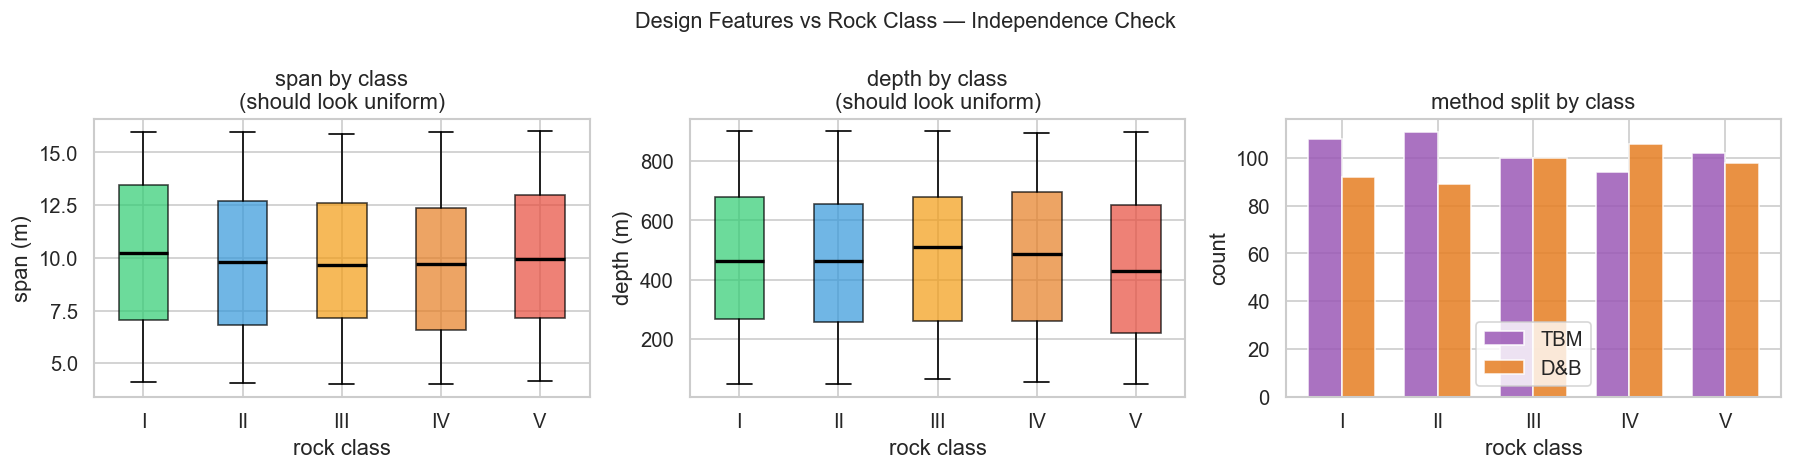

In [12]:
# span and depth should look the same across all classes — they were sampled independently
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

data_span = [df[df[CLASS_COL]==c]['Excavation_Span_m'].values for c in CLASS_ORDER]
bp = axes[0].boxplot(data_span, patch_artist=True, labels=CLASS_ORDER,
                     medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp['boxes'], COLORS_ORDERED):
    patch.set_facecolor(color); patch.set_alpha(0.7)
axes[0].set_xlabel('rock class'); axes[0].set_ylabel('span (m)')
axes[0].set_title('span by class\n(should look uniform)')

data_depth = [df[df[CLASS_COL]==c]['Depth_m'].values for c in CLASS_ORDER]
bp2 = axes[1].boxplot(data_depth, patch_artist=True, labels=CLASS_ORDER,
                      medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp2['boxes'], COLORS_ORDERED):
    patch.set_facecolor(color); patch.set_alpha(0.7)
axes[1].set_xlabel('rock class'); axes[1].set_ylabel('depth (m)')
axes[1].set_title('depth by class\n(should look uniform)')

x = np.arange(len(CLASS_ORDER)); w = 0.35
for method, color, label in [(0, '#9b59b6', 'TBM'), (1, '#e67e22', 'D&B')]:
    counts = [df[(df[CLASS_COL]==c) & (df['Excavation_Method']==method)].shape[0]
              for c in CLASS_ORDER]
    axes[2].bar(x + (w/2 if method==1 else -w/2), counts,
                width=w, color=color, alpha=0.85, edgecolor='white', label=label)
axes[2].set_xticks(x); axes[2].set_xticklabels(CLASS_ORDER)
axes[2].set_xlabel('rock class'); axes[2].set_ylabel('count')
axes[2].set_title('method split by class')
axes[2].legend()

plt.suptitle('Design Features vs Rock Class — Independence Check', fontsize=13)
plt.tight_layout()
plt.savefig('fig4_design_features_by_class.png')
plt.show()

## 5. target variable distributions

RMR (continuous), bolt density (5 discrete values), bolt length + shotcrete (continuous).
within-class spread in the last two comes from span and depth variation.


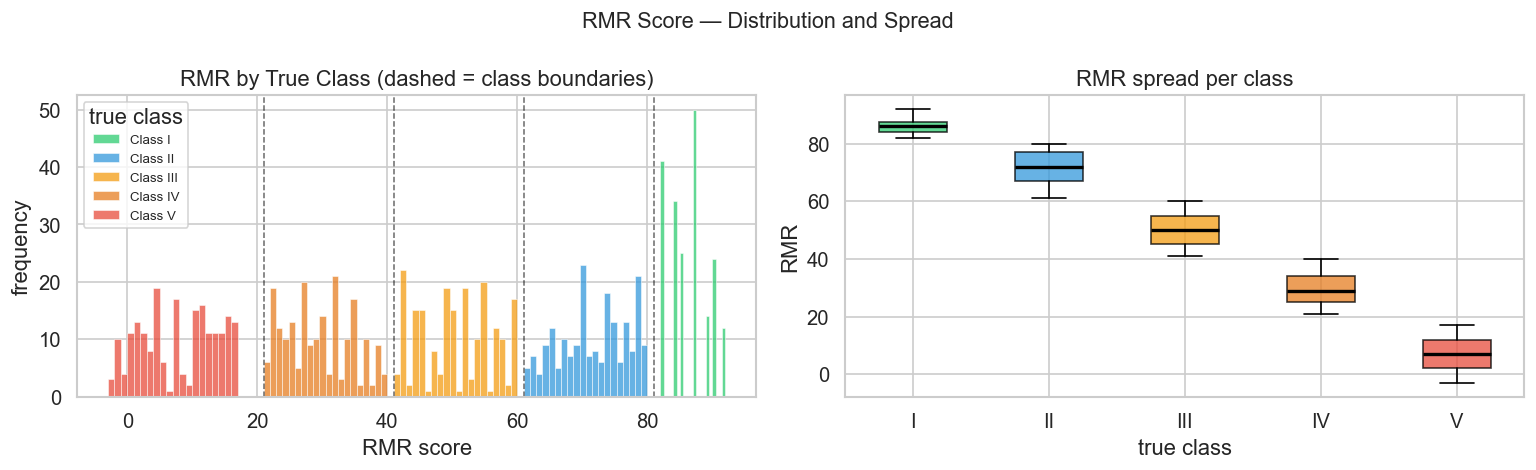

                 min  max  mean  std
True_Rock_Class                     
I                 82   92  86.0  3.0
II                61   80  71.7  5.5
III               41   60  50.5  5.8
IV                21   40  29.4  5.4
V                 -3   17   7.5  5.8


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for cls in CLASS_ORDER:
    axes[0].hist(df[df[CLASS_COL]==cls]['RMR'], bins=20,
                 color=CLASS_COLORS[cls], alpha=0.75,
                 edgecolor='white', linewidth=0.4, label=f'Class {cls}')
for b in [21, 41, 61, 81]:
    axes[0].axvline(b, color='black', linestyle='--', linewidth=0.9, alpha=0.6)
axes[0].set_xlabel('RMR score')
axes[0].set_ylabel('frequency')
axes[0].set_title('RMR by True Class (dashed = class boundaries)')
axes[0].legend(title='true class', fontsize=8)

data_rmr = [df[df[CLASS_COL]==c]['RMR'].values for c in CLASS_ORDER]
bp = axes[1].boxplot(data_rmr, patch_artist=True, labels=CLASS_ORDER,
                     medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp['boxes'], COLORS_ORDERED):
    patch.set_facecolor(color); patch.set_alpha(0.75)
axes[1].set_xlabel('true class'); axes[1].set_ylabel('RMR')
axes[1].set_title('RMR spread per class')

plt.suptitle('RMR Score — Distribution and Spread', fontsize=13)
plt.tight_layout()
plt.savefig('fig5_rmr_distribution.png')
plt.show()

print(df.groupby(CLASS_COL)['RMR'].agg(['min','max','mean','std']).round(1).reindex(CLASS_ORDER))

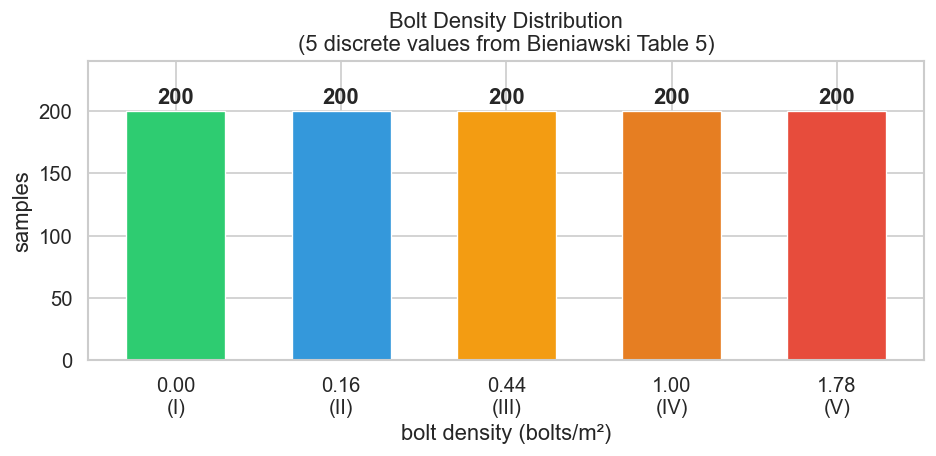

In [15]:
bd_counts = df['Bolt_Density_per_m2'].value_counts().sort_index()
bd_labels = ['0.00\n(I)', '0.16\n(II)', '0.44\n(III)', '1.00\n(IV)', '1.78\n(V)']

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(bd_labels, bd_counts.values, color=COLORS_ORDERED,
              edgecolor='white', linewidth=0.8, width=0.6)
ax.set_xlabel('bolt density (bolts/m²)')
ax.set_ylabel('samples')
ax.set_title('Bolt Density Distribution\n(5 discrete values from Bieniawski Table 5)')
ax.set_ylim(0, max(bd_counts.values) * 1.2)
for bar, val in zip(bars, bd_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
            str(val), ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.savefig('fig6_bolt_density.png')
plt.show()

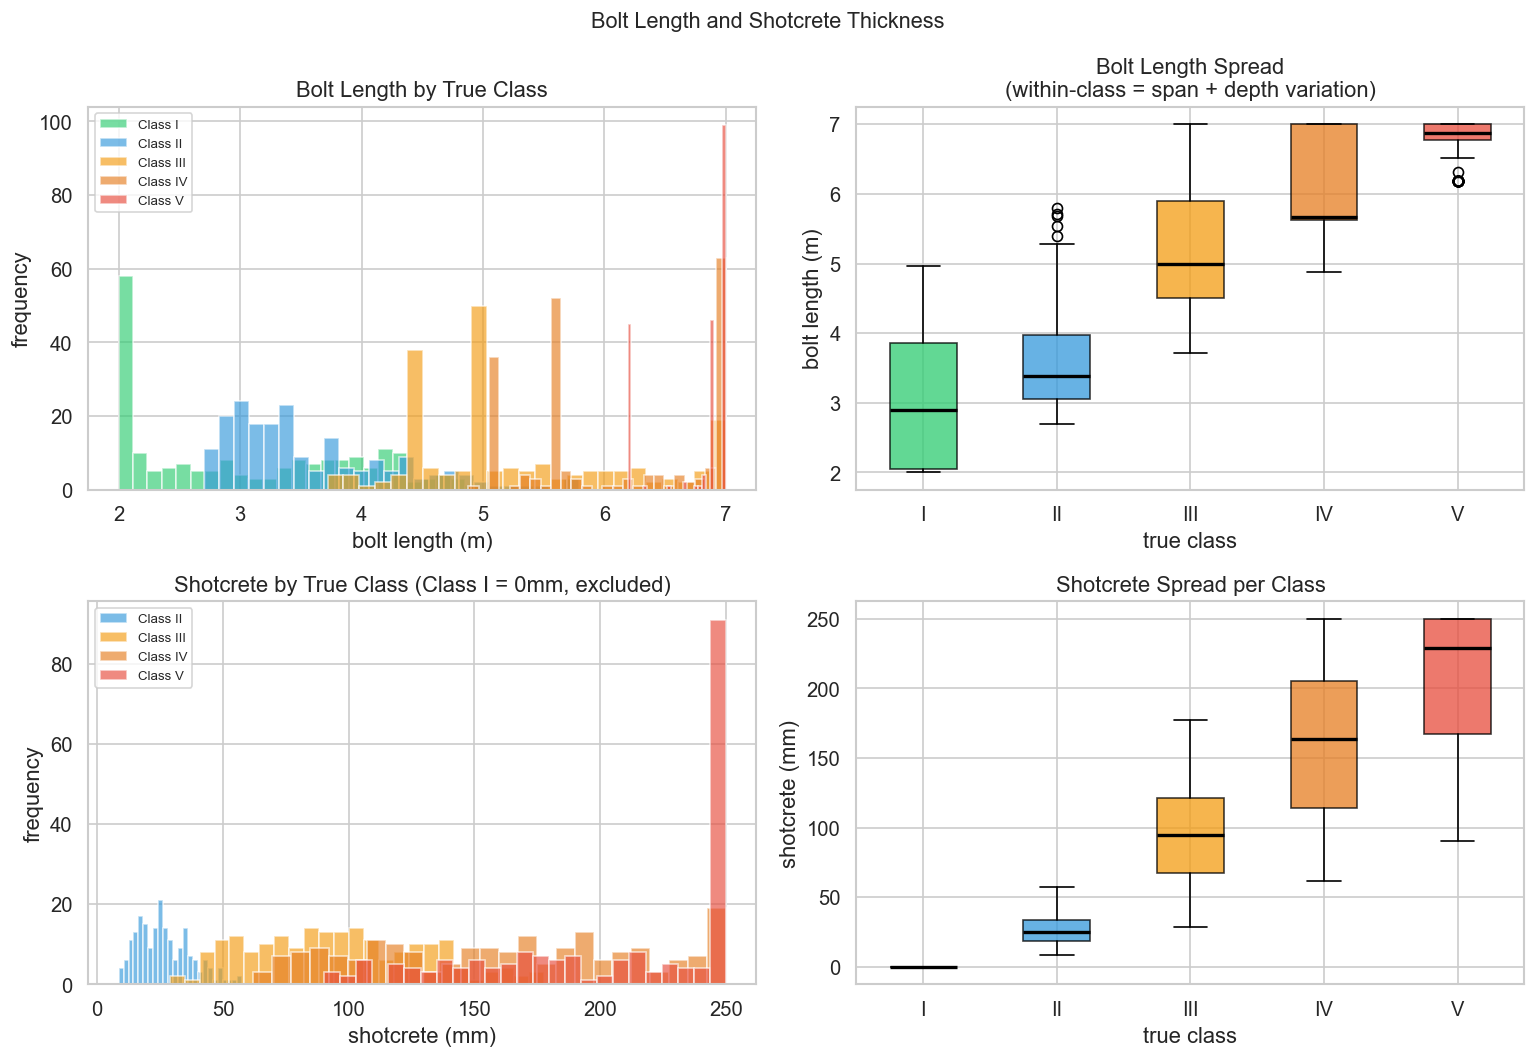

bolt length per class:
                  min   max  mean   std
True_Rock_Class                        
I                2.00  4.97  3.04  0.92
II               2.70  5.79  3.58  0.69
III              3.72  7.00  5.27  0.87
IV               4.88  7.00  6.08  0.77
V                6.19  7.00  6.77  0.33

shotcrete per class:
                  min    max   mean   std
True_Rock_Class                          
I                 0.0    0.0    0.0   0.0
II                8.5   57.7   26.7  10.5
III              28.8  177.5   96.2  34.1
IV               62.0  250.0  162.1  55.1
V                90.2  250.0  206.9  49.6


In [16]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

for cls in CLASS_ORDER:
    axes[0,0].hist(df[df[CLASS_COL]==cls]['Bolt_Length_m'], bins=25,
                   color=CLASS_COLORS[cls], alpha=0.65, edgecolor='white', label=f'Class {cls}')
axes[0,0].set_xlabel('bolt length (m)')
axes[0,0].set_ylabel('frequency')
axes[0,0].set_title('Bolt Length by True Class')
axes[0,0].legend(fontsize=8)

data_bl = [df[df[CLASS_COL]==c]['Bolt_Length_m'].values for c in CLASS_ORDER]
bp = axes[0,1].boxplot(data_bl, patch_artist=True, labels=CLASS_ORDER,
                       medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp['boxes'], COLORS_ORDERED):
    patch.set_facecolor(color); patch.set_alpha(0.75)
axes[0,1].set_xlabel('true class')
axes[0,1].set_ylabel('bolt length (m)')
axes[0,1].set_title('Bolt Length Spread\n(within-class = span + depth variation)')

# skip class I for shotcrete histogram — always 0mm, ruins the axis
for cls in ['II', 'III', 'IV', 'V']:
    axes[1,0].hist(df[df[CLASS_COL]==cls]['Shotcrete_mm'], bins=25,
                   color=CLASS_COLORS[cls], alpha=0.65, edgecolor='white', label=f'Class {cls}')
axes[1,0].set_xlabel('shotcrete (mm)')
axes[1,0].set_ylabel('frequency')
axes[1,0].set_title('Shotcrete by True Class (Class I = 0mm, excluded)')
axes[1,0].legend(fontsize=8)

data_sc = [df[df[CLASS_COL]==c]['Shotcrete_mm'].values for c in CLASS_ORDER]
bp2 = axes[1,1].boxplot(data_sc, patch_artist=True, labels=CLASS_ORDER,
                        medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp2['boxes'], COLORS_ORDERED):
    patch.set_facecolor(color); patch.set_alpha(0.75)
axes[1,1].set_xlabel('true class')
axes[1,1].set_ylabel('shotcrete (mm)')
axes[1,1].set_title('Shotcrete Spread per Class')

plt.suptitle('Bolt Length and Shotcrete Thickness', fontsize=13)
plt.tight_layout()
plt.savefig('fig7_bolt_length_shotcrete.png')
plt.show()

print('bolt length per class:')
print(df.groupby(CLASS_COL)['Bolt_Length_m'].agg(['min','max','mean','std']).round(2).reindex(CLASS_ORDER))
print()
print('shotcrete per class:')
print(df.groupby(CLASS_COL)['Shotcrete_mm'].agg(['min','max','mean','std']).round(1).reindex(CLASS_ORDER))

## 6. span effect on support targets

bolt length and shotcrete should both increase with span — encoding from Rehman 2018
and Lowson & Bieniawski 2013. checking it actually shows up in the data.


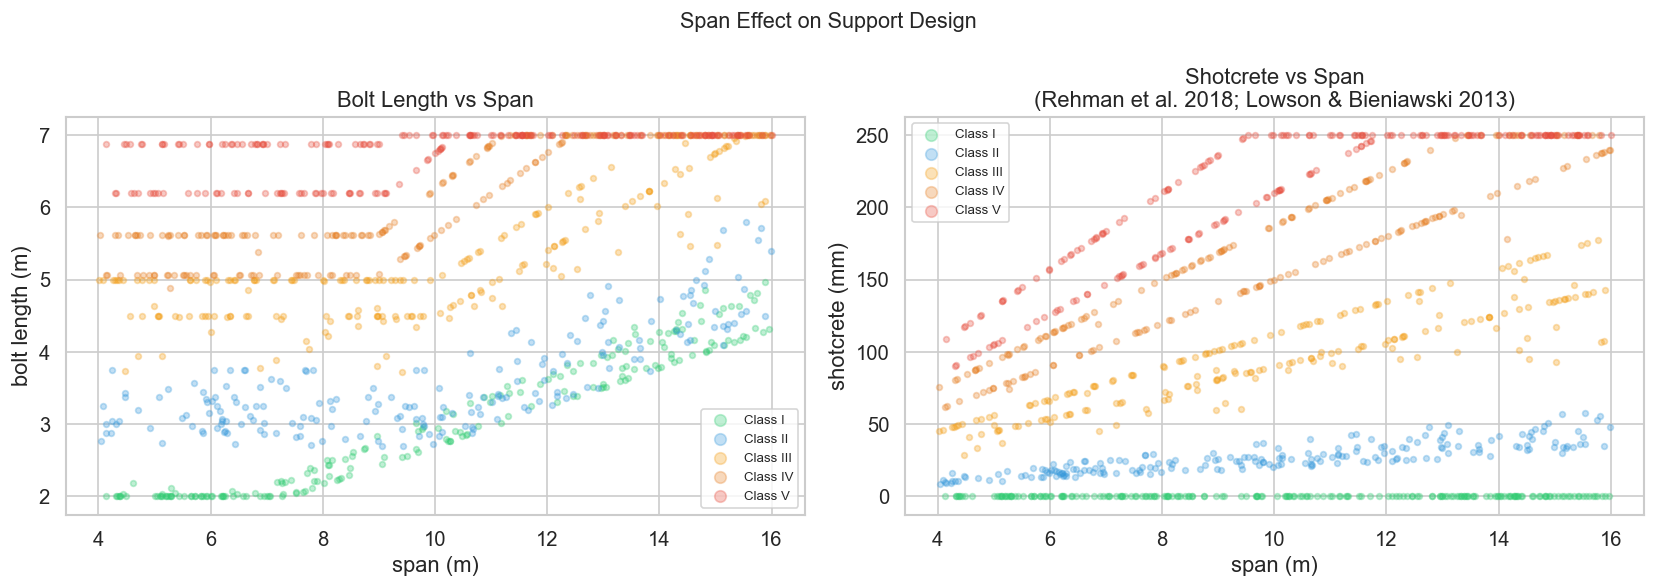

  class      r(span,BL)   r(span,SC)
-----------------------------------
  I              0.9679          nan
  II             0.7475       0.8638
  III            0.8034       0.9030
  IV             0.8773       0.9476
  V              0.5933       0.8873


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for cls in CLASS_ORDER:
    s = df[df[CLASS_COL]==cls]
    axes[0].scatter(s['Excavation_Span_m'], s['Bolt_Length_m'],
                    alpha=0.30, s=12, color=CLASS_COLORS[cls], label=f'Class {cls}')
axes[0].set_xlabel('span (m)')
axes[0].set_ylabel('bolt length (m)')
axes[0].set_title('Bolt Length vs Span')
axes[0].legend(fontsize=8, markerscale=2)

for cls in CLASS_ORDER:
    s = df[df[CLASS_COL]==cls]
    axes[1].scatter(s['Excavation_Span_m'], s['Shotcrete_mm'],
                    alpha=0.30, s=12, color=CLASS_COLORS[cls], label=f'Class {cls}')
axes[1].set_xlabel('span (m)')
axes[1].set_ylabel('shotcrete (mm)')
axes[1].set_title('Shotcrete vs Span\n(Rehman et al. 2018; Lowson & Bieniawski 2013)')
axes[1].legend(fontsize=8, markerscale=2)

plt.suptitle('Span Effect on Support Design', fontsize=13)
plt.tight_layout()
plt.savefig('fig8_span_effect.png')
plt.show()

# per-class correlation to sanity check
print(f'  {"class":<8} {"r(span,BL)":>12} {"r(span,SC)":>12}')
print('-'*35)
for cls in CLASS_ORDER:
    s = df[df[CLASS_COL]==cls]
    r_bl = s['Excavation_Span_m'].corr(s['Bolt_Length_m'])
    r_sc = s['Excavation_Span_m'].corr(s['Shotcrete_mm'])
    print(f'  {cls:<8} {r_bl:>12.4f} {r_sc:>12.4f}')

## 7. depth effect

deeper = higher stress = squeezing possible = more support needed.
class V at depth should show the strongest effect — weakest rock, highest stress ratio.


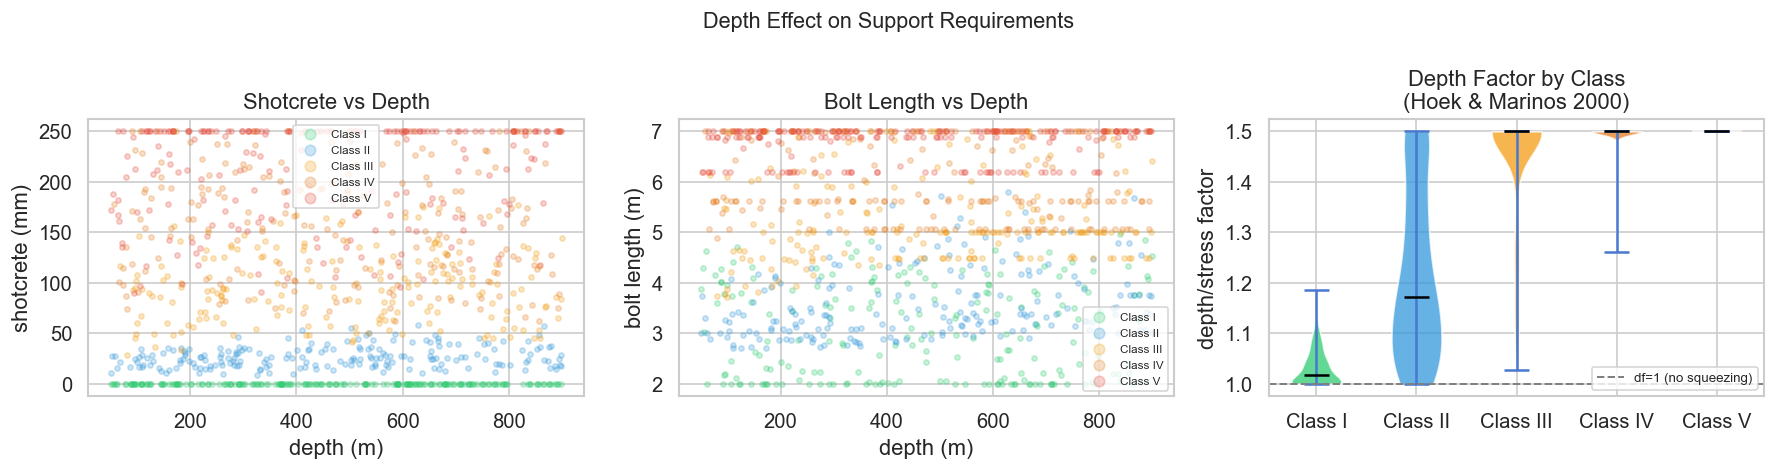

                   min    max   mean
True_Rock_Class                     
I                1.000  1.186  1.032
II               1.000  1.500  1.216
III              1.028  1.500  1.439
IV               1.260  1.500  1.498
V                1.500  1.500  1.500


In [19]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for cls in CLASS_ORDER:
    s = df[df[CLASS_COL]==cls]
    axes[0].scatter(s['Depth_m'], s['Shotcrete_mm'],
                    alpha=0.25, s=10, color=CLASS_COLORS[cls], label=f'Class {cls}')
axes[0].set_xlabel('depth (m)'); axes[0].set_ylabel('shotcrete (mm)')
axes[0].set_title('Shotcrete vs Depth')
axes[0].legend(fontsize=7, markerscale=2)

for cls in CLASS_ORDER:
    s = df[df[CLASS_COL]==cls]
    axes[1].scatter(s['Depth_m'], s['Bolt_Length_m'],
                    alpha=0.25, s=10, color=CLASS_COLORS[cls], label=f'Class {cls}')
axes[1].set_xlabel('depth (m)'); axes[1].set_ylabel('bolt length (m)')
axes[1].set_title('Bolt Length vs Depth')
axes[1].legend(fontsize=7, markerscale=2)

if 'Depth_factor' in df.columns:
    data_df = [df[df[CLASS_COL]==c]['Depth_factor'].values for c in CLASS_ORDER]
    bp = axes[2].violinplot(data_df, positions=range(len(CLASS_ORDER)), showmedians=True)
    for pc, color in zip(bp['bodies'], COLORS_ORDERED):
        pc.set_facecolor(color); pc.set_alpha(0.75)
    bp['cmedians'].set_color('black')
    axes[2].axhline(1.0, color='grey', linewidth=1.2, linestyle='--', label='df=1 (no squeezing)')
    axes[2].set_xticks(range(len(CLASS_ORDER)))
    axes[2].set_xticklabels([f'Class {c}' for c in CLASS_ORDER])
    axes[2].set_ylabel('depth/stress factor')
    axes[2].set_title('Depth Factor by Class\n(Hoek & Marinos 2000)')
    axes[2].legend(fontsize=8)

plt.suptitle('Depth Effect on Support Requirements', fontsize=13)
plt.tight_layout()
plt.savefig('fig9_depth_effect.png')
plt.show()

# class V hits the cap (df=1.5) fairly often at depth — low scm means
# even 300-400m is enough to push sv/scm > 0.2
if 'Depth_factor' in df.columns:
    print(df.groupby(CLASS_COL)['Depth_factor'].agg(['min','max','mean']).round(3).reindex(CLASS_ORDER))

## 8. TBM vs D&B

TBM should give ~10% shorter bolts and ~20% thinner shotcrete vs D&B for same rock class.
directly encoded in the generator — just verifying it comes through cleanly.


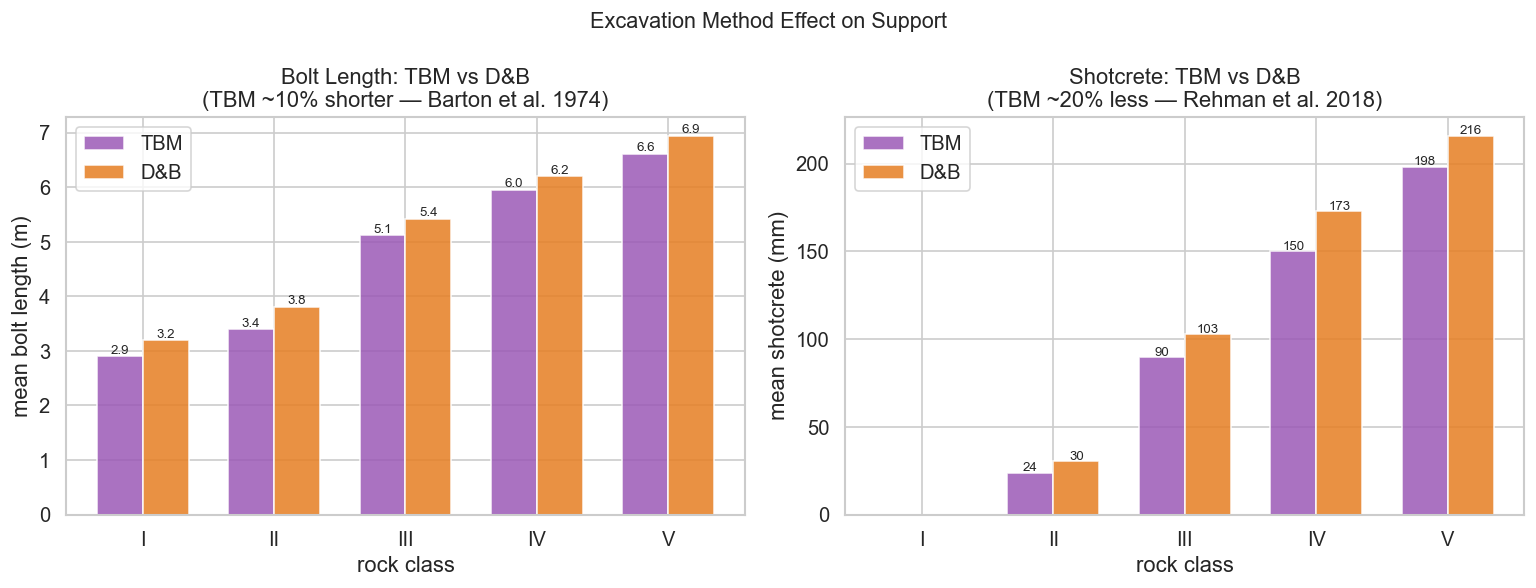

  class    BL_TBM    BL_DB   BL ratio   SC_TBM    SC_DB   SC ratio
-----------------------------------------------------------------
  I          2.90     3.20      0.906      0.0      0.0        nan
  II         3.40     3.81      0.892     23.7     30.4      0.782
  III        5.12     5.43      0.943     89.5    102.9      0.870
  IV         5.95     6.20      0.960    150.0    172.8      0.868
  V          6.61     6.94      0.952    198.2    215.9      0.918


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

method_labels = {0: 'TBM', 1: 'D&B'}
method_colors = {0: '#9b59b6', 1: '#e67e22'}
x = np.arange(len(CLASS_ORDER)); w = 0.35

for method in [0, 1]:
    means = [df[(df[CLASS_COL]==c) & (df['Excavation_Method']==method)]['Bolt_Length_m'].mean()
             for c in CLASS_ORDER]
    offset = -w/2 if method == 0 else w/2
    bars = axes[0].bar(x + offset, means, width=w,
                       color=method_colors[method], alpha=0.85,
                       edgecolor='white', label=method_labels[method])
    for bar, val in zip(bars, means):
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                     f'{val:.1f}', ha='center', fontsize=8)
axes[0].set_xticks(x); axes[0].set_xticklabels(CLASS_ORDER)
axes[0].set_xlabel('rock class'); axes[0].set_ylabel('mean bolt length (m)')
axes[0].set_title('Bolt Length: TBM vs D&B\n(TBM ~10% shorter — Barton et al. 1974)')
axes[0].legend()

for method in [0, 1]:
    means = [df[(df[CLASS_COL]==c) & (df['Excavation_Method']==method)]['Shotcrete_mm'].mean()
             for c in CLASS_ORDER]
    offset = -w/2 if method == 0 else w/2
    bars = axes[1].bar(x + offset, means, width=w,
                       color=method_colors[method], alpha=0.85,
                       edgecolor='white', label=method_labels[method])
    for bar, val in zip(bars, means):
        if val > 2:
            axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                         f'{val:.0f}', ha='center', fontsize=8)
axes[1].set_xticks(x); axes[1].set_xticklabels(CLASS_ORDER)
axes[1].set_xlabel('rock class'); axes[1].set_ylabel('mean shotcrete (mm)')
axes[1].set_title('Shotcrete: TBM vs D&B\n(TBM ~20% less — Rehman et al. 2018)')
axes[1].legend()

plt.suptitle('Excavation Method Effect on Support', fontsize=13)
plt.tight_layout()
plt.savefig('fig10_method_comparison.png')
plt.show()

# check the actual ratios
print(f'  {"class":<6} {"BL_TBM":>8} {"BL_DB":>8} {"BL ratio":>10} {"SC_TBM":>8} {"SC_DB":>8} {"SC ratio":>10}')
print('-'*65)
for cls in CLASS_ORDER:
    bl_tbm = df[(df[CLASS_COL]==cls) & (df['Excavation_Method']==0)]['Bolt_Length_m'].mean()
    bl_db  = df[(df[CLASS_COL]==cls) & (df['Excavation_Method']==1)]['Bolt_Length_m'].mean()
    sc_tbm = df[(df[CLASS_COL]==cls) & (df['Excavation_Method']==0)]['Shotcrete_mm'].mean()
    sc_db  = df[(df[CLASS_COL]==cls) & (df['Excavation_Method']==1)]['Shotcrete_mm'].mean()
    r_bl = bl_tbm/bl_db if bl_db > 0 else float('nan')
    r_sc = sc_tbm/sc_db if sc_db > 0 else float('nan')
    print(f'  {cls:<6} {bl_tbm:>8.2f} {bl_db:>8.2f} {r_bl:>10.3f} {sc_tbm:>8.1f} {sc_db:>8.1f} {r_sc:>10.3f}')

## 9. violin plots — features by class


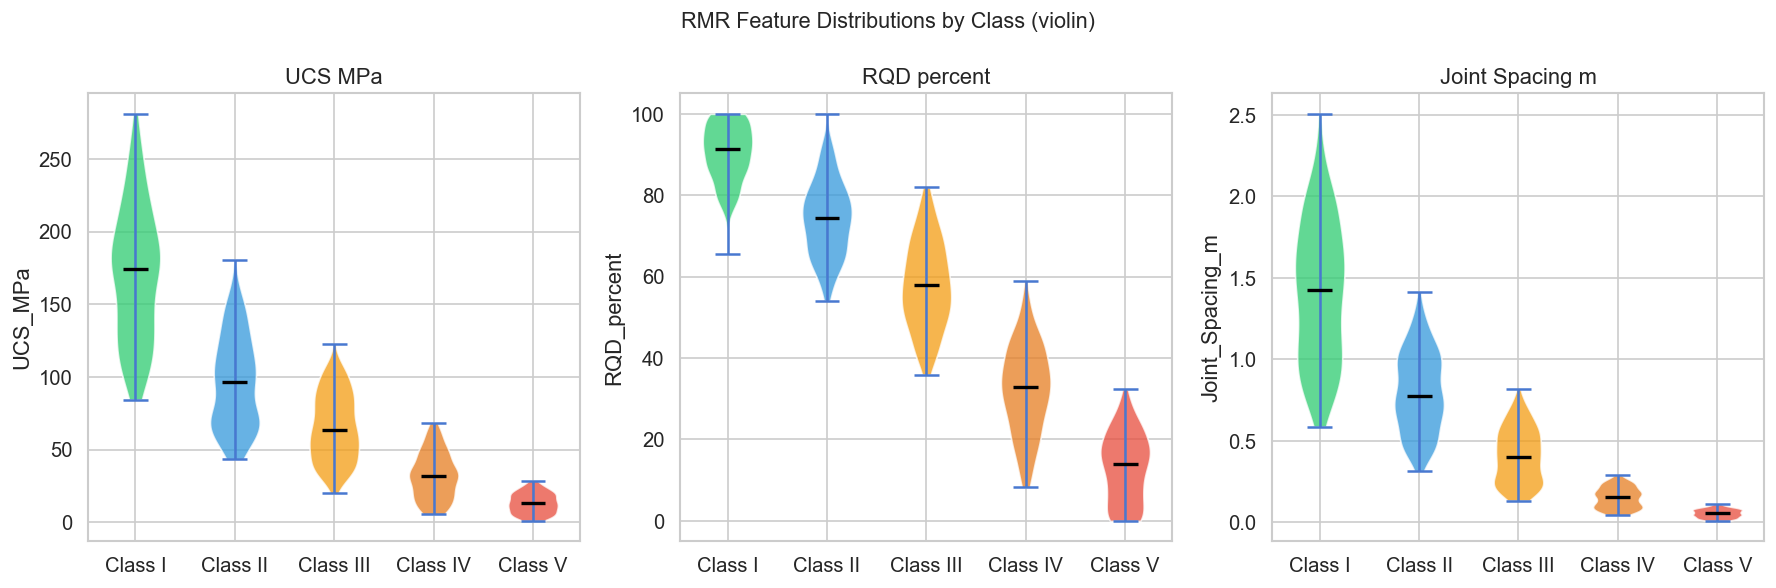

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, feat in enumerate(['UCS_MPa', 'RQD_percent', 'Joint_Spacing_m']):
    ax = axes[i]
    data = [df[df[CLASS_COL]==c][feat].values for c in CLASS_ORDER]
    parts = ax.violinplot(data, positions=range(len(CLASS_ORDER)),
                          showmedians=True, showextrema=True)
    for pc, color in zip(parts['bodies'], COLORS_ORDERED):
        pc.set_facecolor(color); pc.set_alpha(0.75)
    parts['cmedians'].set_color('black')
    parts['cmedians'].set_linewidth(2)
    ax.set_xticks(range(len(CLASS_ORDER)))
    ax.set_xticklabels([f'Class {c}' for c in CLASS_ORDER])
    ax.set_title(feat.replace('_', ' '))
    ax.set_ylabel(feat)

plt.suptitle('RMR Feature Distributions by Class (violin)', fontsize=13)
plt.tight_layout()
plt.savefig('fig11_violin_rmr_features.png')
plt.show()

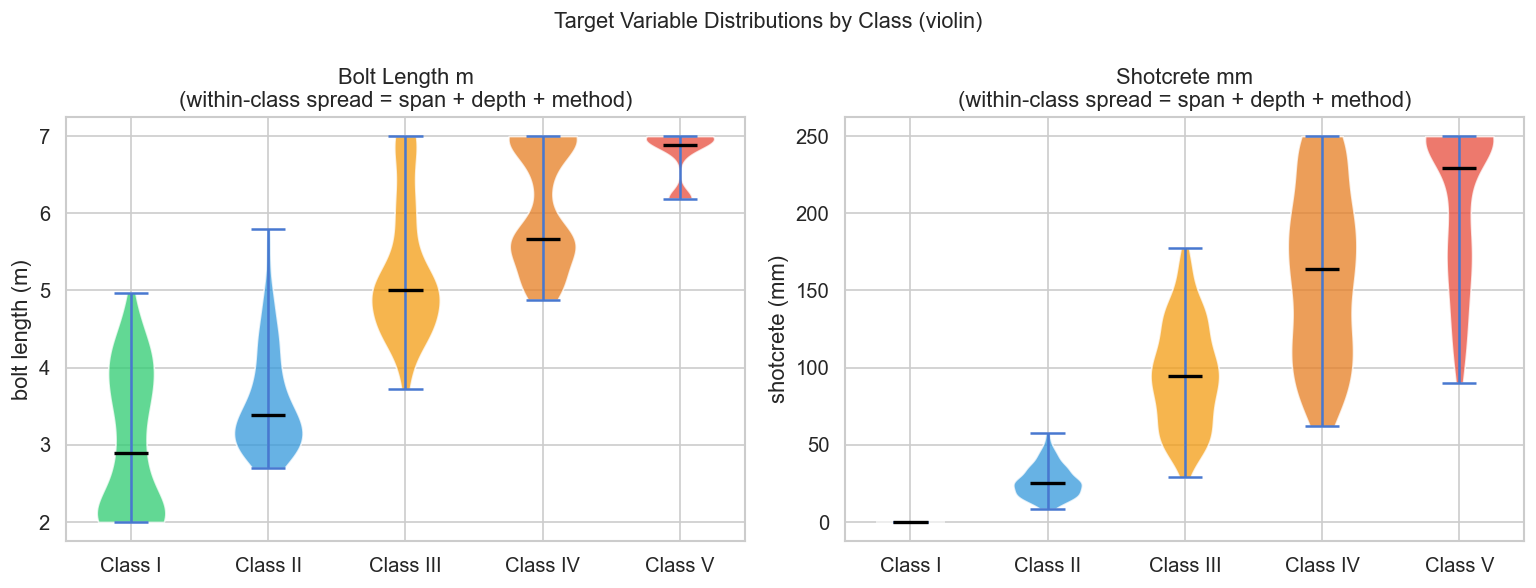

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, feat, ylabel in [
    (axes[0], 'Bolt_Length_m', 'bolt length (m)'),
    (axes[1], 'Shotcrete_mm',  'shotcrete (mm)'),
]:
    data = [df[df[CLASS_COL]==c][feat].values for c in CLASS_ORDER]
    parts = ax.violinplot(data, positions=range(len(CLASS_ORDER)),
                          showmedians=True, showextrema=True)
    for pc, color in zip(parts['bodies'], COLORS_ORDERED):
        pc.set_facecolor(color); pc.set_alpha(0.75)
    parts['cmedians'].set_color('black'); parts['cmedians'].set_linewidth(2)
    ax.set_xticks(range(len(CLASS_ORDER)))
    ax.set_xticklabels([f'Class {c}' for c in CLASS_ORDER])
    ax.set_ylabel(ylabel)
    ax.set_title(f'{feat.replace("_", " ")}\n(within-class spread = span + depth + method)')

plt.suptitle('Target Variable Distributions by Class (violin)', fontsize=13)
plt.tight_layout()
plt.savefig('fig12_violin_targets.png')
plt.show()

## 10. correlation analysis

expecting RMR89 params to correlate with RMR + bolt density,
span to correlate with bolt length + shotcrete


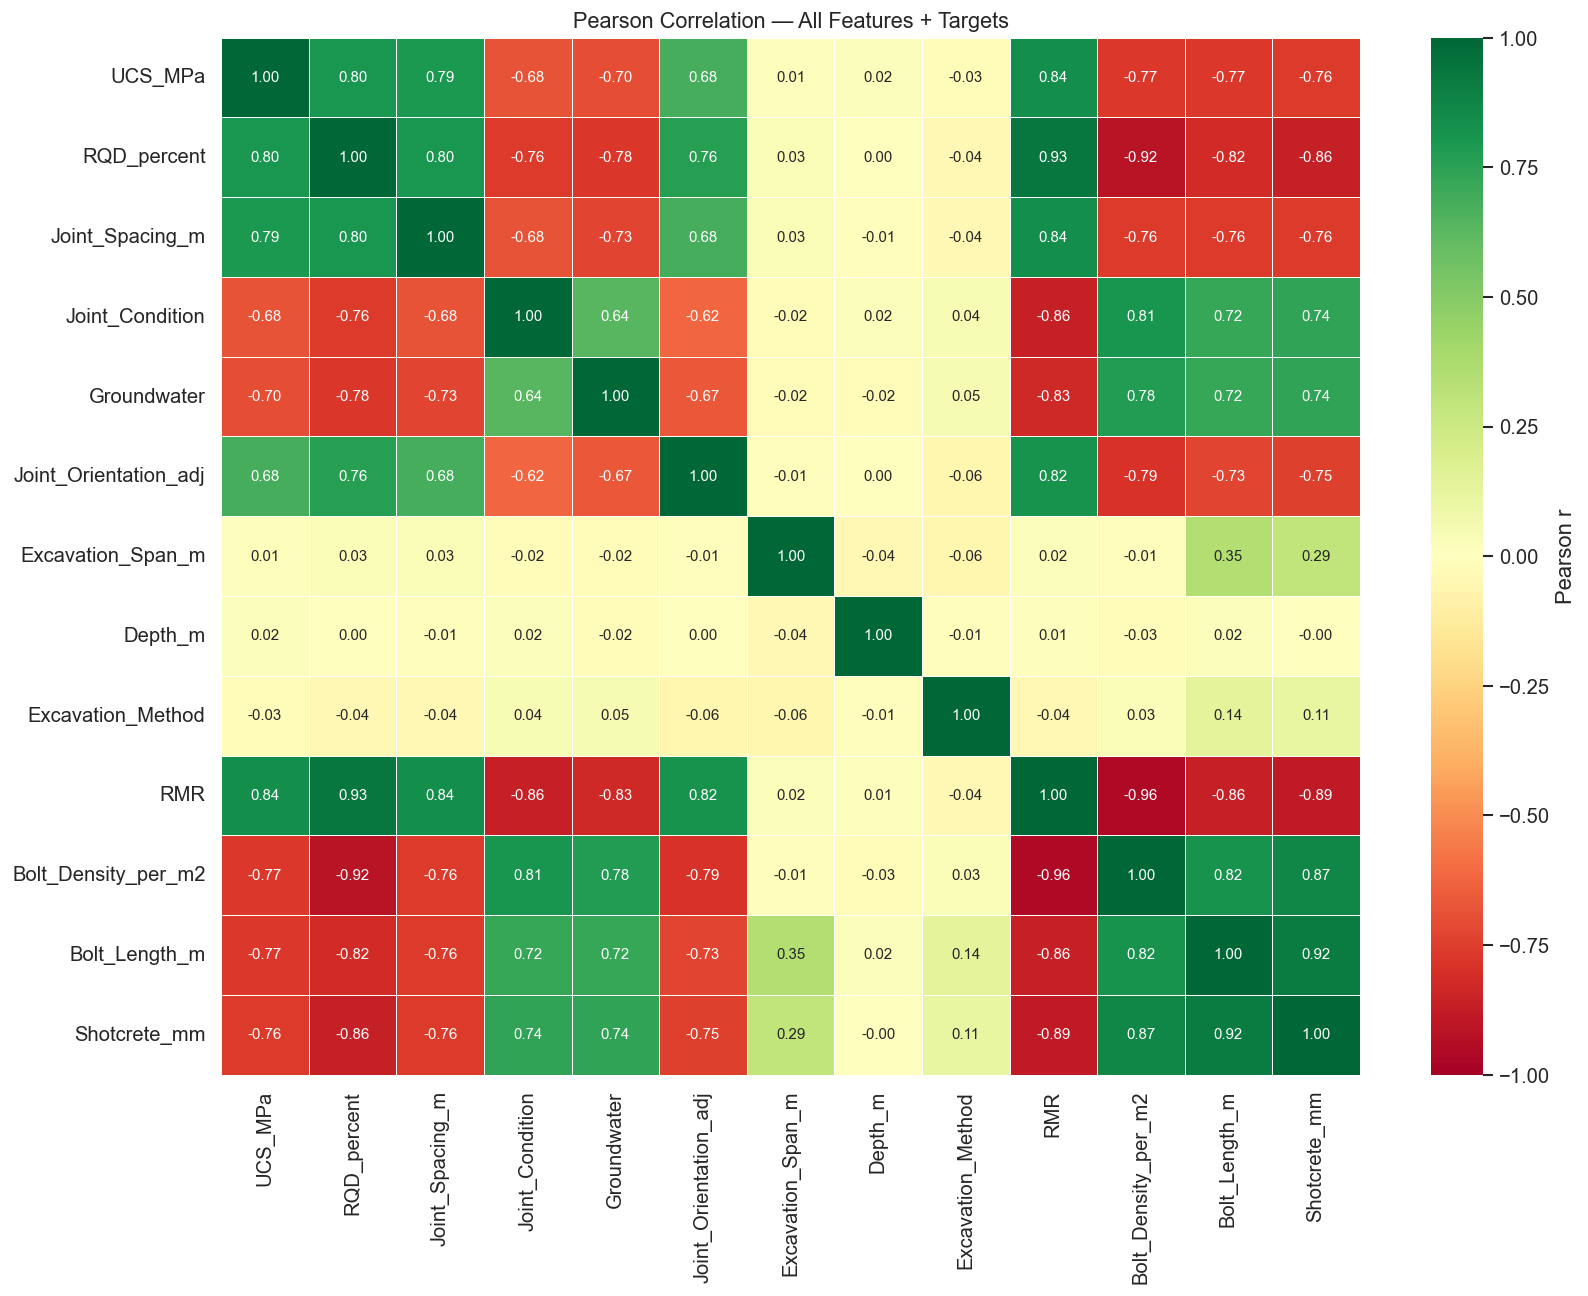


RMR:
  RQD_percent                 : +0.930
  Joint_Condition             : -0.860
  UCS_MPa                     : +0.840
  Joint_Spacing_m             : +0.840
  Groundwater                 : -0.830
  Joint_Orientation_adj       : +0.820
  Excavation_Method           : -0.040
  Excavation_Span_m           : +0.020
  Depth_m                     : +0.010

Bolt_Density_per_m2:
  RQD_percent                 : -0.920
  Joint_Condition             : +0.810
  Joint_Orientation_adj       : -0.790
  Groundwater                 : +0.780
  UCS_MPa                     : -0.770
  Joint_Spacing_m             : -0.760
  Depth_m                     : -0.030
  Excavation_Method           : +0.030
  Excavation_Span_m           : -0.010

Bolt_Length_m:
  RQD_percent                 : -0.820
  UCS_MPa                     : -0.770
  Joint_Spacing_m             : -0.760
  Joint_Orientation_adj       : -0.730
  Joint_Condition             : +0.720
  Groundwater                 : +0.720
  Excavation_Span_m 

In [24]:
numeric_cols = FEATURE_COLS + TARGET_COLS
corr_matrix  = df[numeric_cols].corr().round(2)

# pandas 2.x: corr() now warns if you accidentally include non-numeric cols
# already filtered above so should be clean
fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1,
            linewidths=0.5, linecolor='white', ax=ax,
            cbar_kws={'label': 'Pearson r'}, annot_kws={'size': 9})
ax.set_title('Pearson Correlation — All Features + Targets', fontsize=13)
plt.tight_layout()
plt.savefig('fig13_correlation_matrix.png')
plt.show()

for target in TARGET_COLS:
    top = corr_matrix[target].drop(TARGET_COLS).abs().sort_values(ascending=False)
    print(f'\n{target}:')
    for feat in top.index:
        print(f'  {feat:<28}: {corr_matrix[target][feat]:+.3f}')

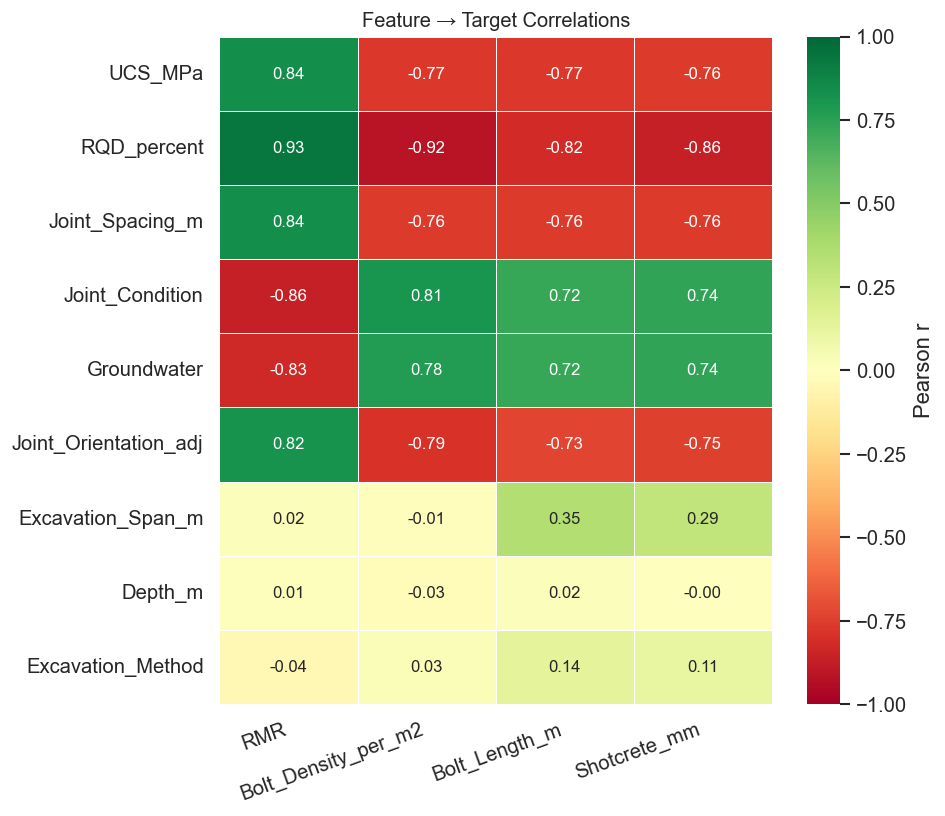

In [25]:
feat_target_corr = corr_matrix.loc[FEATURE_COLS, TARGET_COLS]

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(feat_target_corr, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1,
            linewidths=0.5, linecolor='white', ax=ax,
            cbar_kws={'label': 'Pearson r'}, annot_kws={'size': 10})
ax.set_title('Feature → Target Correlations', fontsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right')
plt.tight_layout()
plt.savefig('fig14_feature_target_correlation.png')
plt.show()

## 11. scatter plots — bolt length & shotcrete vs key predictors


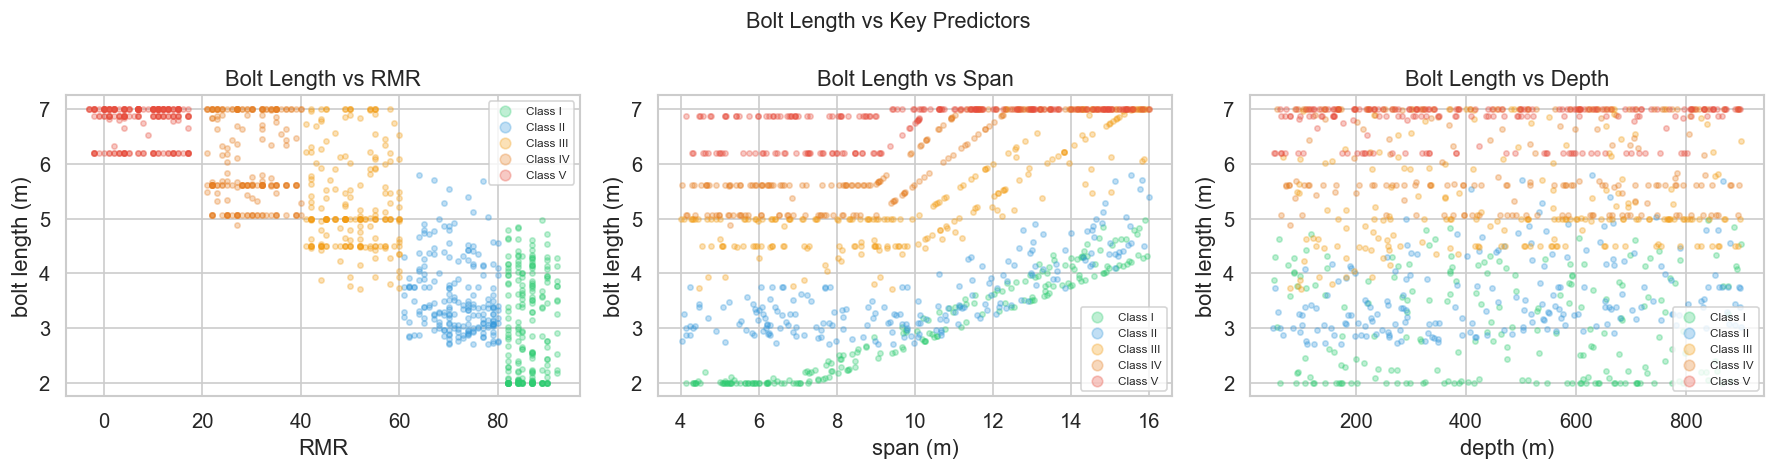

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for cls in CLASS_ORDER:
    s = df[df[CLASS_COL]==cls]
    axes[0].scatter(s['RMR'], s['Bolt_Length_m'],
                    alpha=0.30, s=10, color=CLASS_COLORS[cls], label=f'Class {cls}')
axes[0].set_xlabel('RMR'); axes[0].set_ylabel('bolt length (m)')
axes[0].set_title('Bolt Length vs RMR')
axes[0].legend(fontsize=7, markerscale=2)

for cls in CLASS_ORDER:
    s = df[df[CLASS_COL]==cls]
    axes[1].scatter(s['Excavation_Span_m'], s['Bolt_Length_m'],
                    alpha=0.30, s=10, color=CLASS_COLORS[cls], label=f'Class {cls}')
axes[1].set_xlabel('span (m)'); axes[1].set_ylabel('bolt length (m)')
axes[1].set_title('Bolt Length vs Span')
axes[1].legend(fontsize=7, markerscale=2)

for cls in CLASS_ORDER:
    s = df[df[CLASS_COL]==cls]
    axes[2].scatter(s['Depth_m'], s['Bolt_Length_m'],
                    alpha=0.30, s=10, color=CLASS_COLORS[cls], label=f'Class {cls}')
axes[2].set_xlabel('depth (m)'); axes[2].set_ylabel('bolt length (m)')
axes[2].set_title('Bolt Length vs Depth')
axes[2].legend(fontsize=7, markerscale=2)

plt.suptitle('Bolt Length vs Key Predictors', fontsize=13)
plt.tight_layout()
plt.savefig('fig15_bolt_length_scatter.png')
plt.show()


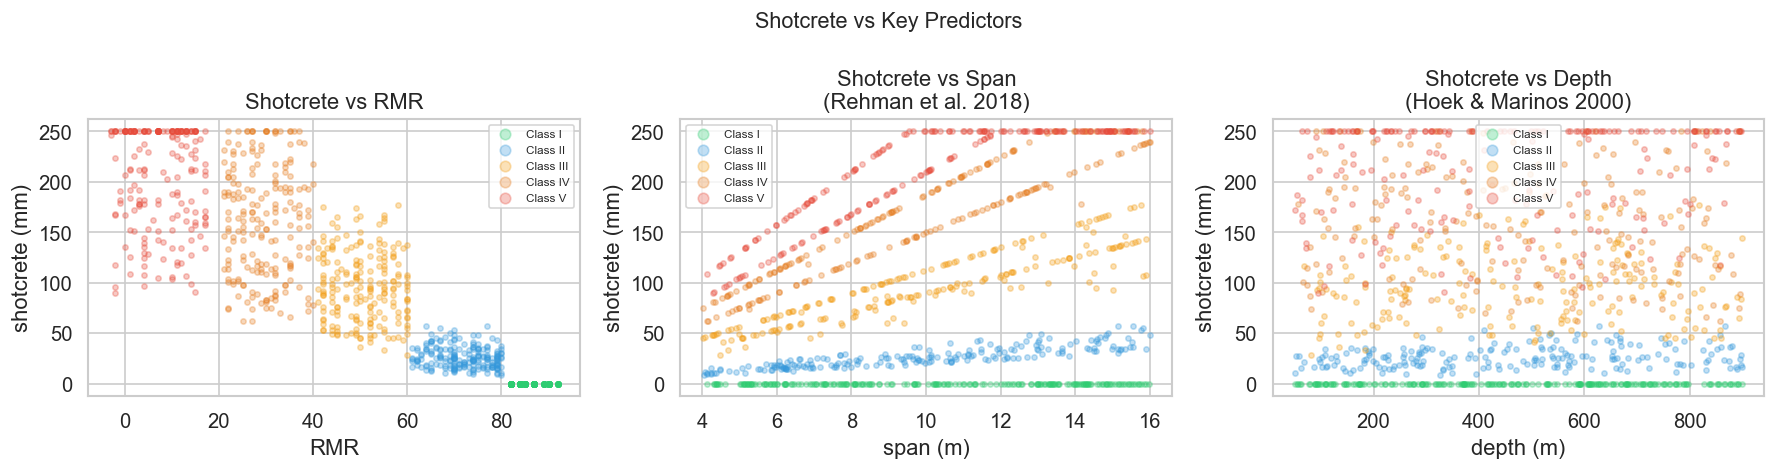

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for cls in CLASS_ORDER:
    s = df[df[CLASS_COL]==cls]
    axes[0].scatter(s['RMR'], s['Shotcrete_mm'],
                    alpha=0.30, s=10, color=CLASS_COLORS[cls], label=f'Class {cls}')
axes[0].set_xlabel('RMR'); axes[0].set_ylabel('shotcrete (mm)')
axes[0].set_title('Shotcrete vs RMR')
axes[0].legend(fontsize=7, markerscale=2)

for cls in CLASS_ORDER:
    s = df[df[CLASS_COL]==cls]
    axes[1].scatter(s['Excavation_Span_m'], s['Shotcrete_mm'],
                    alpha=0.30, s=10, color=CLASS_COLORS[cls], label=f'Class {cls}')
axes[1].set_xlabel('span (m)'); axes[1].set_ylabel('shotcrete (mm)')
axes[1].set_title('Shotcrete vs Span\n(Rehman et al. 2018)')
axes[1].legend(fontsize=7, markerscale=2)

for cls in CLASS_ORDER:
    s = df[df[CLASS_COL]==cls]
    axes[2].scatter(s['Depth_m'], s['Shotcrete_mm'],
                    alpha=0.30, s=10, color=CLASS_COLORS[cls], label=f'Class {cls}')
axes[2].set_xlabel('depth (m)'); axes[2].set_ylabel('shotcrete (mm)')
axes[2].set_title('Shotcrete vs Depth\n(Hoek & Marinos 2000)')
axes[2].legend(fontsize=7, markerscale=2)

plt.suptitle('Shotcrete vs Key Predictors', fontsize=13)
plt.tight_layout()
plt.savefig('fig16_shotcrete_scatter.png')
plt.show()

## 12. noise effect — class boundary shifts


shifted: 105 / 1000 = 10.5%


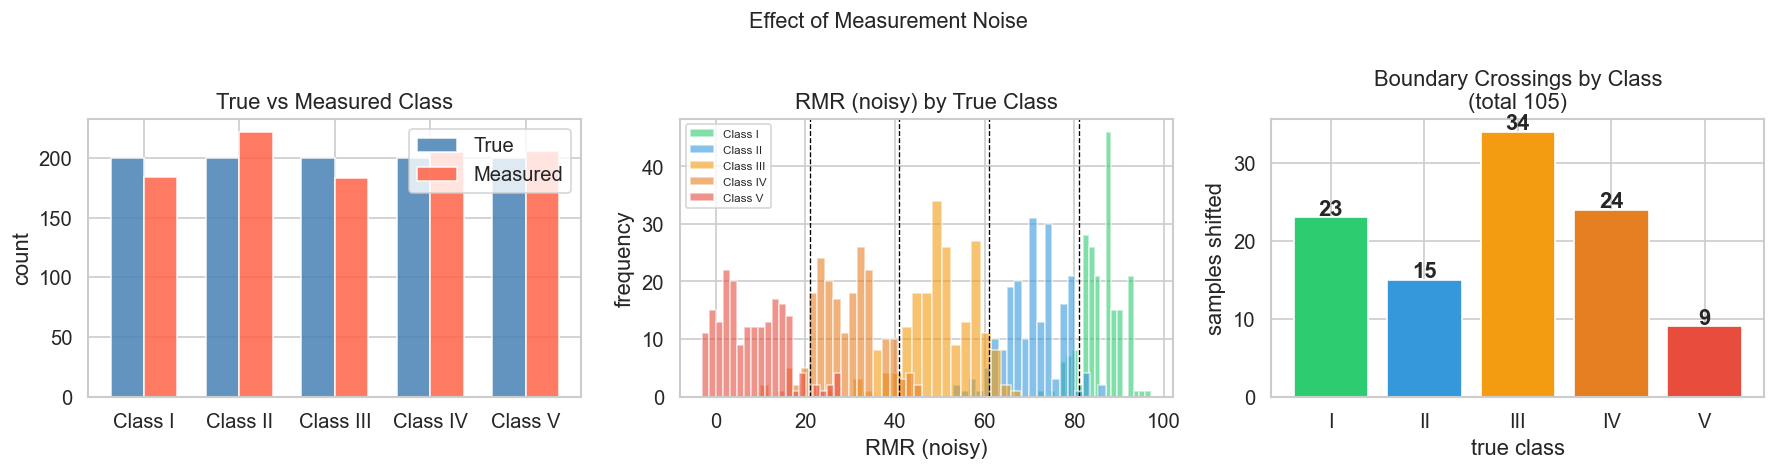

In [29]:
if 'Measured_Rock_Class' in df.columns:
    shifted = (df['True_Rock_Class'] != df['Measured_Rock_Class']).sum()
    print(f'shifted: {shifted} / {len(df)} = {shifted/len(df)*100:.1f}%')

    df['_shifted'] = df['True_Rock_Class'] != df['Measured_Rock_Class']
    shift_by_class = df.groupby('True_Rock_Class')['_shifted'].sum().reindex(CLASS_ORDER)
    df.drop(columns=['_shifted'], inplace=True)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    true_c     = df['True_Rock_Class'].value_counts().reindex(CLASS_ORDER)
    measured_c = df['Measured_Rock_Class'].value_counts().reindex(CLASS_ORDER)
    x = np.arange(len(CLASS_ORDER)); w = 0.35
    axes[0].bar(x - w/2, true_c.values,     width=w, label='True',
                color='steelblue', alpha=0.85, edgecolor='white')
    axes[0].bar(x + w/2, measured_c.values, width=w, label='Measured',
                color='tomato', alpha=0.85, edgecolor='white')
    axes[0].set_xticks(x)
    axes[0].set_xticklabels([f'Class {c}' for c in CLASS_ORDER])
    axes[0].set_title('True vs Measured Class')
    axes[0].set_ylabel('count')
    axes[0].legend()

    # recompute RMR from the noisy measured inputs
    JC = {1:30, 2:25, 3:20, 4:10, 5:0}
    GW = {1:15, 2:10, 3:7,  4:4,  5:0}
    for cls in CLASS_ORDER:
        mask = df['True_Rock_Class'] == cls
        rmr_noisy = df[mask].apply(lambda r: (
            (15 if r.UCS_MPa>250 else 12 if r.UCS_MPa>100 else 7 if r.UCS_MPa>50
             else 4 if r.UCS_MPa>25 else 2 if r.UCS_MPa>5 else 1) +
            (20 if r.RQD_percent>=90 else 17 if r.RQD_percent>=75 else
             13 if r.RQD_percent>=50 else 8 if r.RQD_percent>=25 else 3) +
            (20 if r.Joint_Spacing_m>2 else 15 if r.Joint_Spacing_m>0.6 else
             10 if r.Joint_Spacing_m>0.2 else 8 if r.Joint_Spacing_m>0.06 else 5) +
            JC[r.Joint_Condition] + GW[r.Groundwater] + r.Joint_Orientation_adj
        ), axis=1)
        axes[1].hist(rmr_noisy, bins=20, alpha=0.6,
                     color=CLASS_COLORS[cls], edgecolor='white', label=f'Class {cls}')
    for b in [21, 41, 61, 81]:
        axes[1].axvline(b, color='black', linewidth=0.8, linestyle='--')
    axes[1].set_xlabel('RMR (noisy)'); axes[1].set_ylabel('frequency')
    axes[1].set_title('RMR (noisy) by True Class')
    axes[1].legend(fontsize=7)

    bars = axes[2].bar(CLASS_ORDER, shift_by_class.values,
                       color=COLORS_ORDERED, edgecolor='white')
    for bar, v in zip(bars, shift_by_class.values):
        axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                     str(v), ha='center', fontweight='bold')
    axes[2].set_xlabel('true class'); axes[2].set_ylabel('samples shifted')
    axes[2].set_title(f'Boundary Crossings by Class\n(total {shifted})')

    plt.suptitle('Effect of Measurement Noise', fontsize=13)
    plt.tight_layout()
    plt.savefig('fig17_noise_effect.png')
    plt.show()
else:
    print('Measured_Rock_Class column not found')

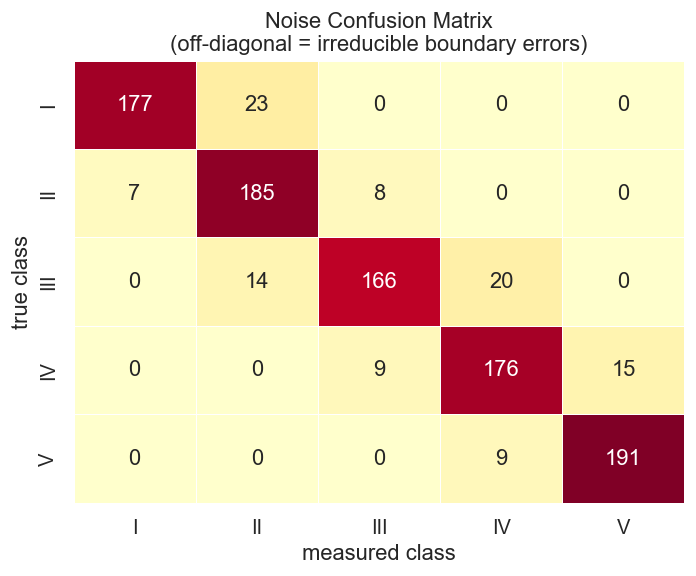

off-diagonal total: 105


In [30]:
if 'Measured_Rock_Class' in df.columns:
    cm = confusion_matrix(df['True_Rock_Class'], df['Measured_Rock_Class'], labels=CLASS_ORDER)
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrRd',
                xticklabels=CLASS_ORDER, yticklabels=CLASS_ORDER,
                linewidths=0.5, ax=ax, cbar=False)
    ax.set_xlabel('measured class')
    ax.set_ylabel('true class')
    ax.set_title('Noise Confusion Matrix\n(off-diagonal = irreducible boundary errors)')
    plt.tight_layout()
    plt.savefig('fig18_noise_confusion.png')
    plt.show()
    # off-diagonal sets the realistic accuracy ceiling for any classifier
    print(f'off-diagonal total: {cm.sum() - np.trace(cm)}')

## 13. outlier check — IQR

UCS outliers expected given how wide the class I range is vs class V


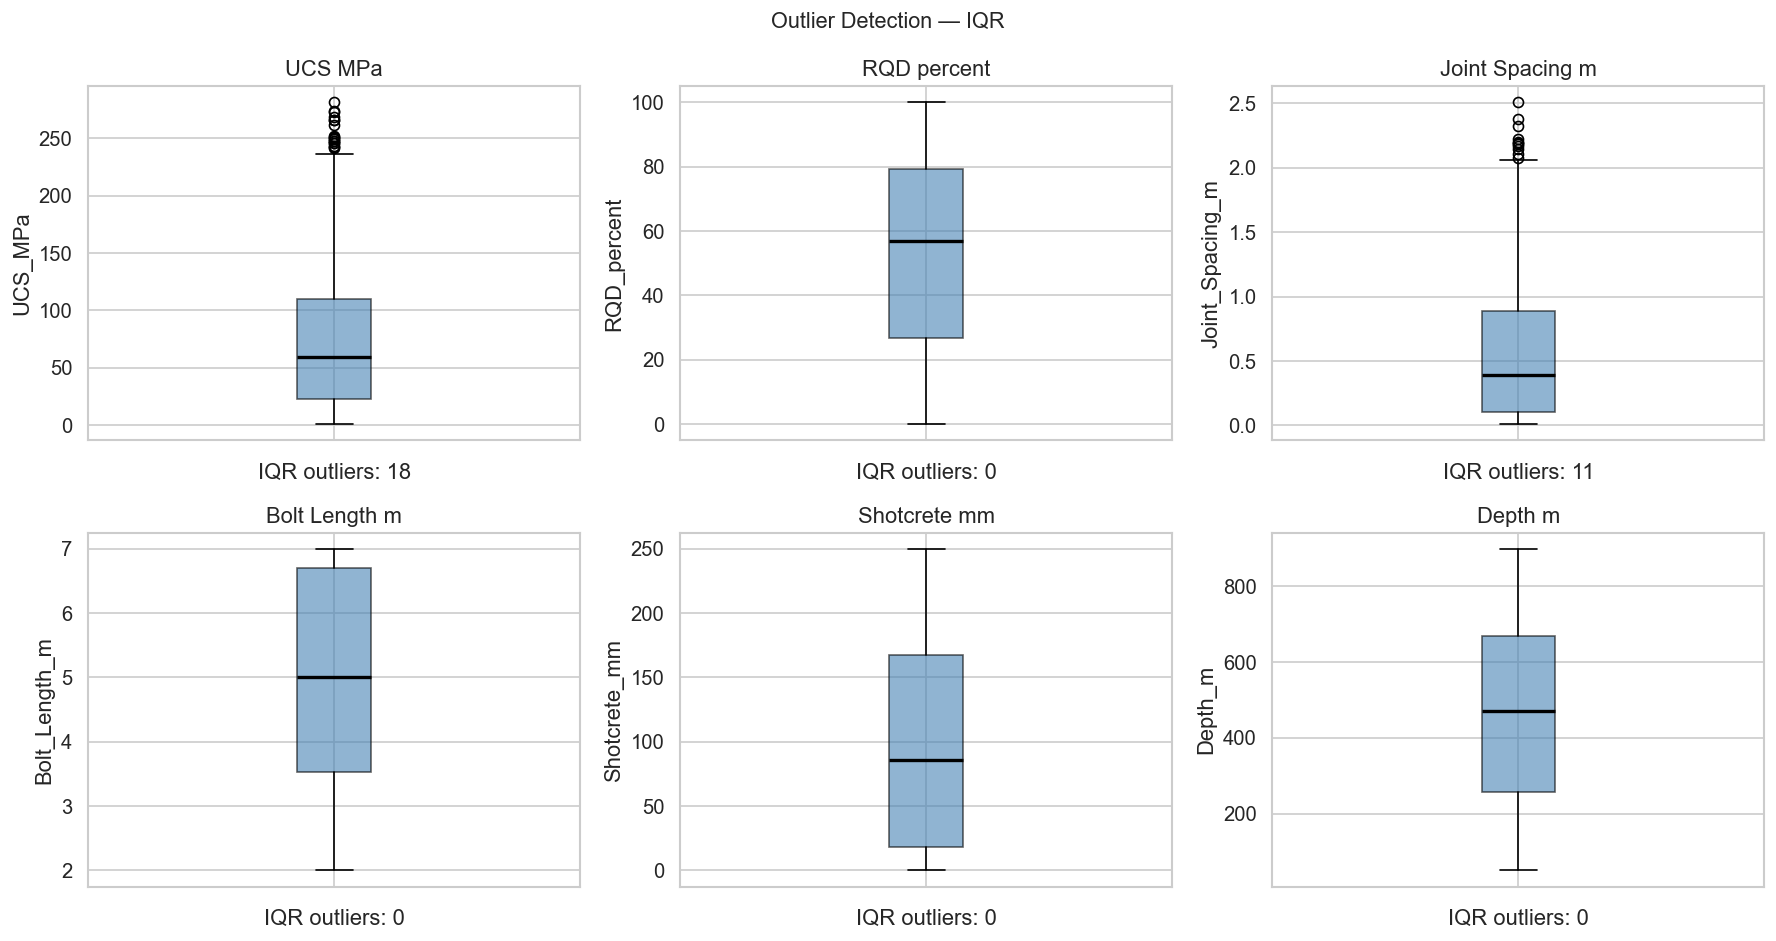

In [32]:
check_cols = ['UCS_MPa', 'RQD_percent', 'Joint_Spacing_m',
              'Bolt_Length_m', 'Shotcrete_mm', 'Depth_m']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for ax, feat in zip(axes.flat, check_cols):
    ax.boxplot(df[feat], vert=True, patch_artist=True,
               boxprops=dict(facecolor='steelblue', alpha=0.6),
               medianprops=dict(color='black', linewidth=2))
    ax.set_title(feat.replace('_', ' '))
    ax.set_ylabel(feat)
    ax.set_xticklabels([])
    Q1  = df[feat].quantile(0.25)
    Q3  = df[feat].quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((df[feat] < Q1 - 1.5*IQR) | (df[feat] > Q3 + 1.5*IQR)).sum()
    ax.set_xlabel(f'IQR outliers: {n_out}')

plt.suptitle('Outlier Detection — IQR', fontsize=13)
plt.tight_layout()
plt.savefig('fig19_outliers.png')
plt.show()

## 14. ANOVA F-tests

higher F = stronger class separator. span/depth/method should score near zero
since they were sampled independently — that's actually what we want, confirms
they bring new information not already in the RMR89 params.


feature                                   F              p
----------------------------------------------------------
UCS_MPa                               962.7       0.00e+00  ***
RQD_percent                          2181.3       0.00e+00  ***
Joint_Spacing_m                      1088.5       0.00e+00  ***
Joint_Condition                       540.1      1.48e-247  ***
Groundwater                           512.8      6.11e-240  ***
Joint_Orientation_adj                 505.1      9.11e-238  ***
Excavation_Span_m                       0.5       7.53e-01  n.s.
Depth_m                                 0.8       5.01e-01  n.s.
Excavation_Method                       0.9       4.64e-01  n.s.


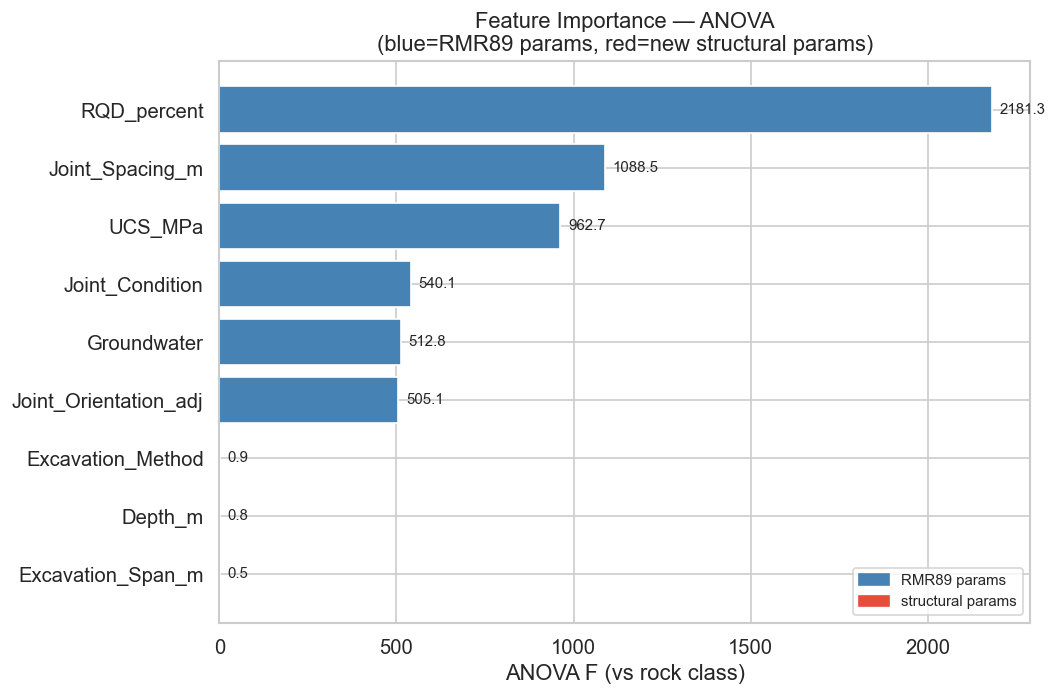

In [33]:
f_scores = {}
print(f'{"feature":<30} {"F":>12} {"p":>14}')
print('-'*58)
for feat in FEATURE_COLS:
    groups = [df[df[CLASS_COL]==c][feat].values for c in CLASS_ORDER]
    f_stat, p_val = stats.f_oneway(*groups)
    f_scores[feat] = f_stat
    sig = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else 'n.s.'
    print(f'{feat:<30} {f_stat:>12.1f} {p_val:>14.2e}  {sig}')

fi_df = pd.DataFrame({'feature': list(f_scores.keys()),
                      'F': list(f_scores.values())}).sort_values('F')
bar_colors = ['#e74c3c' if f in NEW_FEATURE_COLS else 'steelblue' for f in fi_df['feature']]

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(fi_df['feature'], fi_df['F'], color=bar_colors, edgecolor='white')
ax.set_xlabel('ANOVA F (vs rock class)')
ax.set_title('Feature Importance — ANOVA\n(blue=RMR89 params, red=new structural params)')
for i, (_, row) in enumerate(fi_df.iterrows()):
    ax.text(row['F'] + max(fi_df['F'])*0.01, i, f"{row['F']:.1f}", va='center', fontsize=9)
ax.legend(handles=[
    mpatches.Patch(color='steelblue', label='RMR89 params'),
    mpatches.Patch(color='#e74c3c',   label='structural params'),
], fontsize=9)
plt.tight_layout()
plt.savefig('fig20_anova.png')
plt.show()

# span/depth/method near-zero F is expected and good — means they're orthogonal to class

## 15. summary stats per class


In [36]:
df.groupby(CLASS_COL)[TARGET_COLS + ['Excavation_Span_m', 'Depth_m']]\
  .agg(['mean', 'std']).round(2).reindex(CLASS_ORDER)

RMR       Bolt_Density_per_m2      Bolt_Length_m        \
                  mean   std                mean  std          mean   std   
True_Rock_Class                                                             
I                86.02  3.02                0.00  0.0          3.04  0.92   
II               71.66  5.49                0.16  0.0          3.58  0.69   
III              50.50  5.81                0.44  0.0          5.27  0.87   
IV               29.38  5.36                1.00  0.0          6.08  0.77   
V                 7.46  5.80                1.78  0.0          6.77  0.33   

                Shotcrete_mm        Excavation_Span_m       Depth_m          
                        mean    std              mean   std    mean     std  
True_Rock_Class                                                              
I                       0.00   0.00             10.17  3.58  466.62  244.93  
II                     26.68  10.47              9.88  3.38  462.03  240.23  
III                    96.19  34.13              9.98  3.42  486.64  237.89  
IV                    162.08  55.06              9.71  3.39  478.72  248.13  
V                     206.91  49.63              9.99  3.37  445.49  253.30

In [38]:
ct = pd.crosstab(df['True_Rock_Class'], df['Excavation_Method'].map({0:'TBM', 1:'D&B'}))
ct.index.name = 'rock class'
print(ct.reindex(CLASS_ORDER))

Excavation_Method  D&B  TBM
rock class                 
I                   92  108
II                  89  111
III                100  100
IV                 106   94
V                   98  102


## 16. EDA summary


In [41]:
shifted_pct = (
    (df['True_Rock_Class'] != df['Measured_Rock_Class']).mean() * 100
    if 'Measured_Rock_Class' in df.columns else 0.0
)
fi_sorted = pd.Series(f_scores).sort_values(ascending=False)

print(f'samples: {len(df)}')
print(f'features: {len(FEATURE_COLS)}')
print(f'targets:{TARGET_COLS}')
print(f'missing: {df.isnull().sum().sum()}')
print(f'noise-shifted: {shifted_pct:.1f}%')
print(f'class balance: {dict(df[CLASS_COL].value_counts().sort_index())}')
print()
print('target ranges:')
for col in TARGET_COLS:
    print(f' {col:<25}: {df[col].min():.2f} – {df[col].max():.2f}  (mean {df[col].mean():.2f})')
print()
print(f'span: {df.Excavation_Span_m.min()} – {df.Excavation_Span_m.max()} m')
print(f'depth: {df.Depth_m.min()} – {df.Depth_m.max()} m')
print(f'method: TBM={(df.Excavation_Method==0).sum()}  D&B={(df.Excavation_Method==1).sum()}')
print()
print('ANOVA ranking:')
for feat, val in fi_sorted.items():
    tag = '[Design Parameters]'if feat in NEW_FEATURE_COLS else '     '
    print(f' {tag} {feat:<28}: {val:.1f}')
print()
print('main takeaways:')
print('  - span/depth have near-zero F -> orthogonal to rock class, adds real info')
print('  - shotcrete and bolt length both go up with span, down with RMR')
print('  - TBM consistently ~10-20% less support than D&B across all classes')
print('  - class V at depth >400m frequently hits df_cap=1.5 (squeezing)')
print('  - within-class variance is substantial -> class alone not enough for design')

samples: 1000
features: 9
targets:['RMR', 'Bolt_Density_per_m2', 'Bolt_Length_m', 'Shotcrete_mm']
missing: 0
noise-shifted: 10.5%
class balance: {'I': np.int64(200), 'II': np.int64(200), 'III': np.int64(200), 'IV': np.int64(200), 'V': np.int64(200)}

target ranges:
 RMR                      : -3.00 – 92.00  (mean 49.00)
 Bolt_Density_per_m2      : 0.00 – 1.78  (mean 0.68)
 Bolt_Length_m            : 2.00 – 7.00  (mean 4.95)
 Shotcrete_mm             : 0.00 – 250.00  (mean 98.37)

span: 4.02 – 16.0 m
depth: 50.3 – 899.4 m
method: TBM=515  D&B=485

ANOVA ranking:
       RQD_percent                 : 2181.3
       Joint_Spacing_m             : 1088.5
       UCS_MPa                     : 962.7
       Joint_Condition             : 540.1
       Groundwater                 : 512.8
       Joint_Orientation_adj       : 505.1
 [Design Parameters] Excavation_Method           : 0.9
 [Design Parameters] Depth_m                     : 0.8
 [Design Parameters] Excavation_Span_m           : 0.5

main t